# Parte A — EDA: Percepção dos Brasileiros sobre o Racismo no Brasil

**Pesquisa:** CESOP / IPEC / 04829  
**Período de campo:** 14–18 de abril de 2023  
**Amostra:** 2.000 entrevistas — eleitores de 16 anos ou mais  
**Margem de erro:** ± 2 p.p. (95% de confiança)

---

## Sumário

1. [Setup e Carregamento](#1)
2. [Perfil da Amostra](#2)
3. [Análise 1 — Paradoxo da Consciência Racial](#3)
4. [Análise 2 — Distância Social do Racismo](#4)
5. [Análise 3 — Anatomia do Apoio às Cotas](#5)
6. [Análise 4 — Motor das Desigualdades: Raça ou Classe?](#6)
7. [Análise 5 — Definição Popular de Racismo](#7)
8. [Análise 6 — Percepção do Racismo Policial](#8)
9. [Correlação Externa 1 — PNAD 2023: Desigualdade Salarial por Raça](#9)
10. [Correlação Externa 2 — TSE 2022: Representatividade Racial dos Eleitos](#10)
11. [Correlação Externa 3 — CNJ 2023: Composição Racial do Judiciário](#11)
12. [PCA — Dimensões Latentes na Percepção do Racismo](#12)
13. [Conclusões](#13)

---

## Introdução

O racismo é um fenômeno estrutural que permeia diversas dimensões da sociedade brasileira — do mercado de trabalho ao sistema de justiça, passando pela representação política e pelo cotidiano das famílias. Apesar de amplamente reconhecido em discurso, sua manifestação concreta e suas causas ainda são objeto de percepções divergentes entre diferentes grupos populacionais.

Este trabalho analisa os dados da **Pesquisa 04829 — Percepção dos Brasileiros sobre o Racismo no Brasil**, conduzida pelo CESOP/IPEC em abril de 2023 com 2.000 eleitores de 16 anos ou mais, distribuídos em 127 municípios brasileiros. A pesquisa oferece um retrato detalhado de como diferentes grupos populacionais — segmentados por raça/cor, renda, escolaridade, região e posição política — percebem o racismo, suas manifestações e as políticas públicas voltadas ao combate à desigualdade racial.

As perguntas centrais que orientam este EDA são:

- Existe um **paradoxo** entre reconhecer o racismo estrutural e assumir responsabilidade individual por atitudes racistas?
- Como a percepção do racismo varia conforme a proximidade com a esfera pessoal do respondente?
- O apoio a políticas afirmativas (cotas) segue lógica de identidade racial ou de posicionamento político?
- A desigualdade racial **real** — medida por PNAD, TSE e CNJ — é percebida de forma proporcional à sua magnitude?

---

## Métodos

### Fonte de Dados Principal

| Item | Detalhe |
|------|---------|
| Pesquisa | CESOP/IPEC 04829 — Percepção dos Brasileiros sobre o Racismo no Brasil |
| Período de campo | 14 a 18 de abril de 2023 |
| Amostra | 2.000 entrevistas presenciais |
| Universo | Eleitores de 16 anos ou mais, Brasil |
| Margem de erro | ± 2 p.p. (95% de confiança) |
| Formato | Arquivo SAV (SPSS), lido com `pyreadstat` |

### Bases Externas Correlacionadas (recorte 2023)

| Base | Fonte | Variáveis utilizadas |
|------|-------|----------------------|
| PNAD Contínua Anual | IBGE / SIDRA (Tab. 10374 e 10372) | Rendimento médio e horas trabalhadas por raça e UF |
| Candidatos e eleitos 2022 | TSE — Repositório Eleitoral | % negros entre candidatos e eleitos por cargo e UF |
| Censo do Poder Judiciário | CNJ — DataJud 2023 | Composição racial por cargo (servidores, juízes, desembargadores) |

### Técnicas Empregadas

- **Análise exploratória univariada e bivariada** com `matplotlib` e `seaborn`
- **Binarização de escalas Likert**: concordo totalmente/em parte → 1; demais → 0
- **Tratamento correto de variáveis de resposta múltipla cascateada** (P7, P8): a opção é buscada em todas as posições da sequência, não apenas na última
- **Teste qui-quadrado** (`scipy.stats`) para avaliar associações entre variáveis categóricas
- **Correlação de Pearson** entre percepções CESOP e indicadores externos por UF
- **Análise de Componentes Principais (PCA)** sobre os itens P5 para identificar dimensões latentes na percepção do racismo
- **Índice de Dissonância Cognitiva Racial (IDCR)**: gap percentual entre concordância com "o Brasil é racista" (P5A) e "tenho atitudes racistas" (P5C), por grupo racial

## 1. Setup e Carregamento <a id='1'></a>

In [1]:
!pip install pyreadstat prince --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 3.1 MB/s eta 0:00:00


In [2]:
# ============================================================
# DOWNLOAD DOS DADOS DO GITHUB
# ============================================================
import urllib.request, os

GITHUB_RAW = "https://raw.githubusercontent.com/IMT-CD-PAPA/IMT_CD_PROJETO_1/main/parte_a_pesquisa_opiniao/dados/"
GITHUB_EXT = GITHUB_RAW + "dados_externos/"

os.makedirs("dados_externos", exist_ok=True)

def baixar(url, dest):
    if not os.path.exists(dest):
        try:
            urllib.request.urlretrieve(url, dest)
            print(f"✓ {dest}")
        except Exception as e:
            print(f"⚠ Erro em {dest}: {e}")
    else:
        print(f"✓ {dest} (já existe)")

baixar(GITHUB_RAW + "04829.SAV", "04829.SAV")
for arq in ["tabela10374.csv","tabela10372.csv","tabela10361.xlsx",
            "consulta_cand_2022_BRASIL.csv"]:
    baixar(GITHUB_EXT + arq, f"dados_externos/{arq}")

✓ 04829.SAV
✓ dados_externos/tabela10374.csv
✓ dados_externos/tabela10372.csv
✓ dados_externos/tabela10361.xlsx
✓ dados_externos/consulta_cand_2022_BRASIL.csv


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi':130,'figure.facecolor':'white',
                     'axes.titlesize':12,'axes.titleweight':'bold'})

COR_RACA = {'Branca':'#4C72B0','Preta':'#2d2d2d','Parda':'#C4874F',
            'Amarela':'#F5C518','Indígena':'#2ca02c'}

MAPA_UF_COD = {11:'RO',12:'AC',13:'AM',14:'RR',15:'PA',16:'AP',17:'TO',
               21:'MA',22:'PI',23:'CE',24:'RN',25:'PB',26:'PE',27:'AL',
               28:'SE',29:'BA',31:'MG',32:'ES',33:'RJ',35:'SP',
               41:'PR',42:'SC',43:'RS',50:'MS',51:'MT',52:'GO',53:'DF'}

MAPA_NOME_SIGLA = {
    'Rondônia':'RO','Acre':'AC','Amazonas':'AM','Roraima':'RR','Pará':'PA',
    'Amapá':'AP','Tocantins':'TO','Maranhão':'MA','Piauí':'PI','Ceará':'CE',
    'Rio Grande do Norte':'RN','Paraíba':'PB','Pernambuco':'PE','Alagoas':'AL',
    'Sergipe':'SE','Bahia':'BA','Minas Gerais':'MG','Espírito Santo':'ES',
    'Rio de Janeiro':'RJ','São Paulo':'SP','Paraná':'PR','Santa Catarina':'SC',
    'Rio Grande do Sul':'RS','Mato Grosso do Sul':'MS','Mato Grosso':'MT',
    'Goiás':'GO','Distrito Federal':'DF'
}

MAPA_REGIAO = {
    'RO':'Norte','AC':'Norte','AM':'Norte','RR':'Norte','PA':'Norte','AP':'Norte','TO':'Norte',
    'MA':'Nordeste','PI':'Nordeste','CE':'Nordeste','RN':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','AL':'Nordeste','SE':'Nordeste','BA':'Nordeste',
    'MG':'Sudeste','ES':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','SC':'Sul','RS':'Sul',
    'MS':'Centro-Oeste','MT':'Centro-Oeste','GO':'Centro-Oeste','DF':'Centro-Oeste'
}
COR_REGIAO = {'Norte':'#2ecc71','Nordeste':'#e74c3c','Sudeste':'#3498db',
              'Sul':'#9b59b6','Centro-Oeste':'#f39c12'}

print('✓ Imports OK')

✓ Imports OK


In [4]:
# ============================================================
# CARREGAMENTO E PRÉ-PROCESSAMENTO DO CESOP
# ============================================================
df_raw, meta = pyreadstat.read_sav('04829.SAV')
df = df_raw.copy()

df['raca_label'] = df['RACA'].map({1:'Branca',2:'Preta',3:'Parda',4:'Amarela',5:'Indígena'})
df['raca_grupo'] = df['RACA'].map({1:'Branca',2:'Negra',3:'Negra',4:'Outras',5:'Outras'})
df['sexo_label'] = df['SEXO'].map({1:'Masculino',2:'Feminino'})
df['fxidade_label'] = df['FX_ID'].map({1:'16-24',2:'25-34',3:'35-44',4:'45-59',5:'60+'})
df['regiao_label'] = df['REGIAO'].map({1:'Norte',2:'Nordeste',3:'Sudeste',4:'Sul',5:'Centro-Oeste'})
df['politica_label'] = df['P_POLITICA'].map({1:'Esquerda',2:'Centro',3:'Direita',4:'Sem posição',99:None})
df['uf_sigla'] = df['UF'].map(MAPA_UF_COD)
df['p1_label'] = df['P1'].map({1:'Raça/Cor/Etnia',2:'Classe Social',3:'Gênero/Sexo',
                                4:'Local de Moradia',5:'Deficiência',6:'Orient. Sexual',
                                7:'Local de Origem',97:'Nenhuma/Outras',99:None})

def escolaridade_grupo(x):
    if pd.isna(x): return None
    if x<=7: return 'Fundamental I'
    elif x<=11: return 'Fundamental II'
    elif x<=14: return 'Ensino Médio'
    elif x==15: return 'Superior Inc.'
    elif x==16: return 'Superior Comp.'
    return None

df['escol_grupo'] = df['ESCOLARIDADE'].apply(escolaridade_grupo)
ORDEM_ESCOL = ['Fundamental I','Fundamental II','Ensino Médio','Superior Inc.','Superior Comp.']

df['renda_label'] = df['REND2'].map({1:'Mais de 20 SM',2:'10-20 SM',3:'5-10 SM',
                                      4:'2-5 SM',5:'1-2 SM',6:'Até 1 SM',99:None})
ORDEM_RENDA = ['Até 1 SM','1-2 SM','2-5 SM','5-10 SM','10-20 SM']

# Binarizar P5 (Likert: 1 ou 2 → concorda)
ITENS_P5 = {'P5A':'Brasil é racista','P5B':'Eu sofri racismo',
             'P5C':'Tenho atitudes racistas','P5D':'Presenciei racismo',
             'P5G':'Convivo c/ vítimas','P5H':'Convivo c/ quem age racista',
             'P5I':'Minha família é racista'}
for col in ITENS_P5:
    df[col+'_bin'] = df[col].apply(lambda x: 1 if x in [1,2] else (np.nan if x in [98,99] else 0))

# Helper: resposta múltipla cascateada (P7, P8...)
def escolheu_rm(df_in, opcao, prefixo, n_max=13):
    """Verdadeiro se respondente escolheu a opção em qualquer posição da RM."""
    mask = pd.Series(False, index=df_in.index)
    for i in range(1, n_max+1):
        col = f'{prefixo}_{i}'
        if col in df_in.columns:
            mask = mask | (df_in[col] == float(opcao))
    return mask

print(f'✓ CESOP carregado: {df.shape[0]} entrevistas, {df.shape[1]} variáveis')

✓ CESOP carregado: 2000 entrevistas, 161 variáveis


---
## 2. Perfil da Amostra <a id='2'></a>

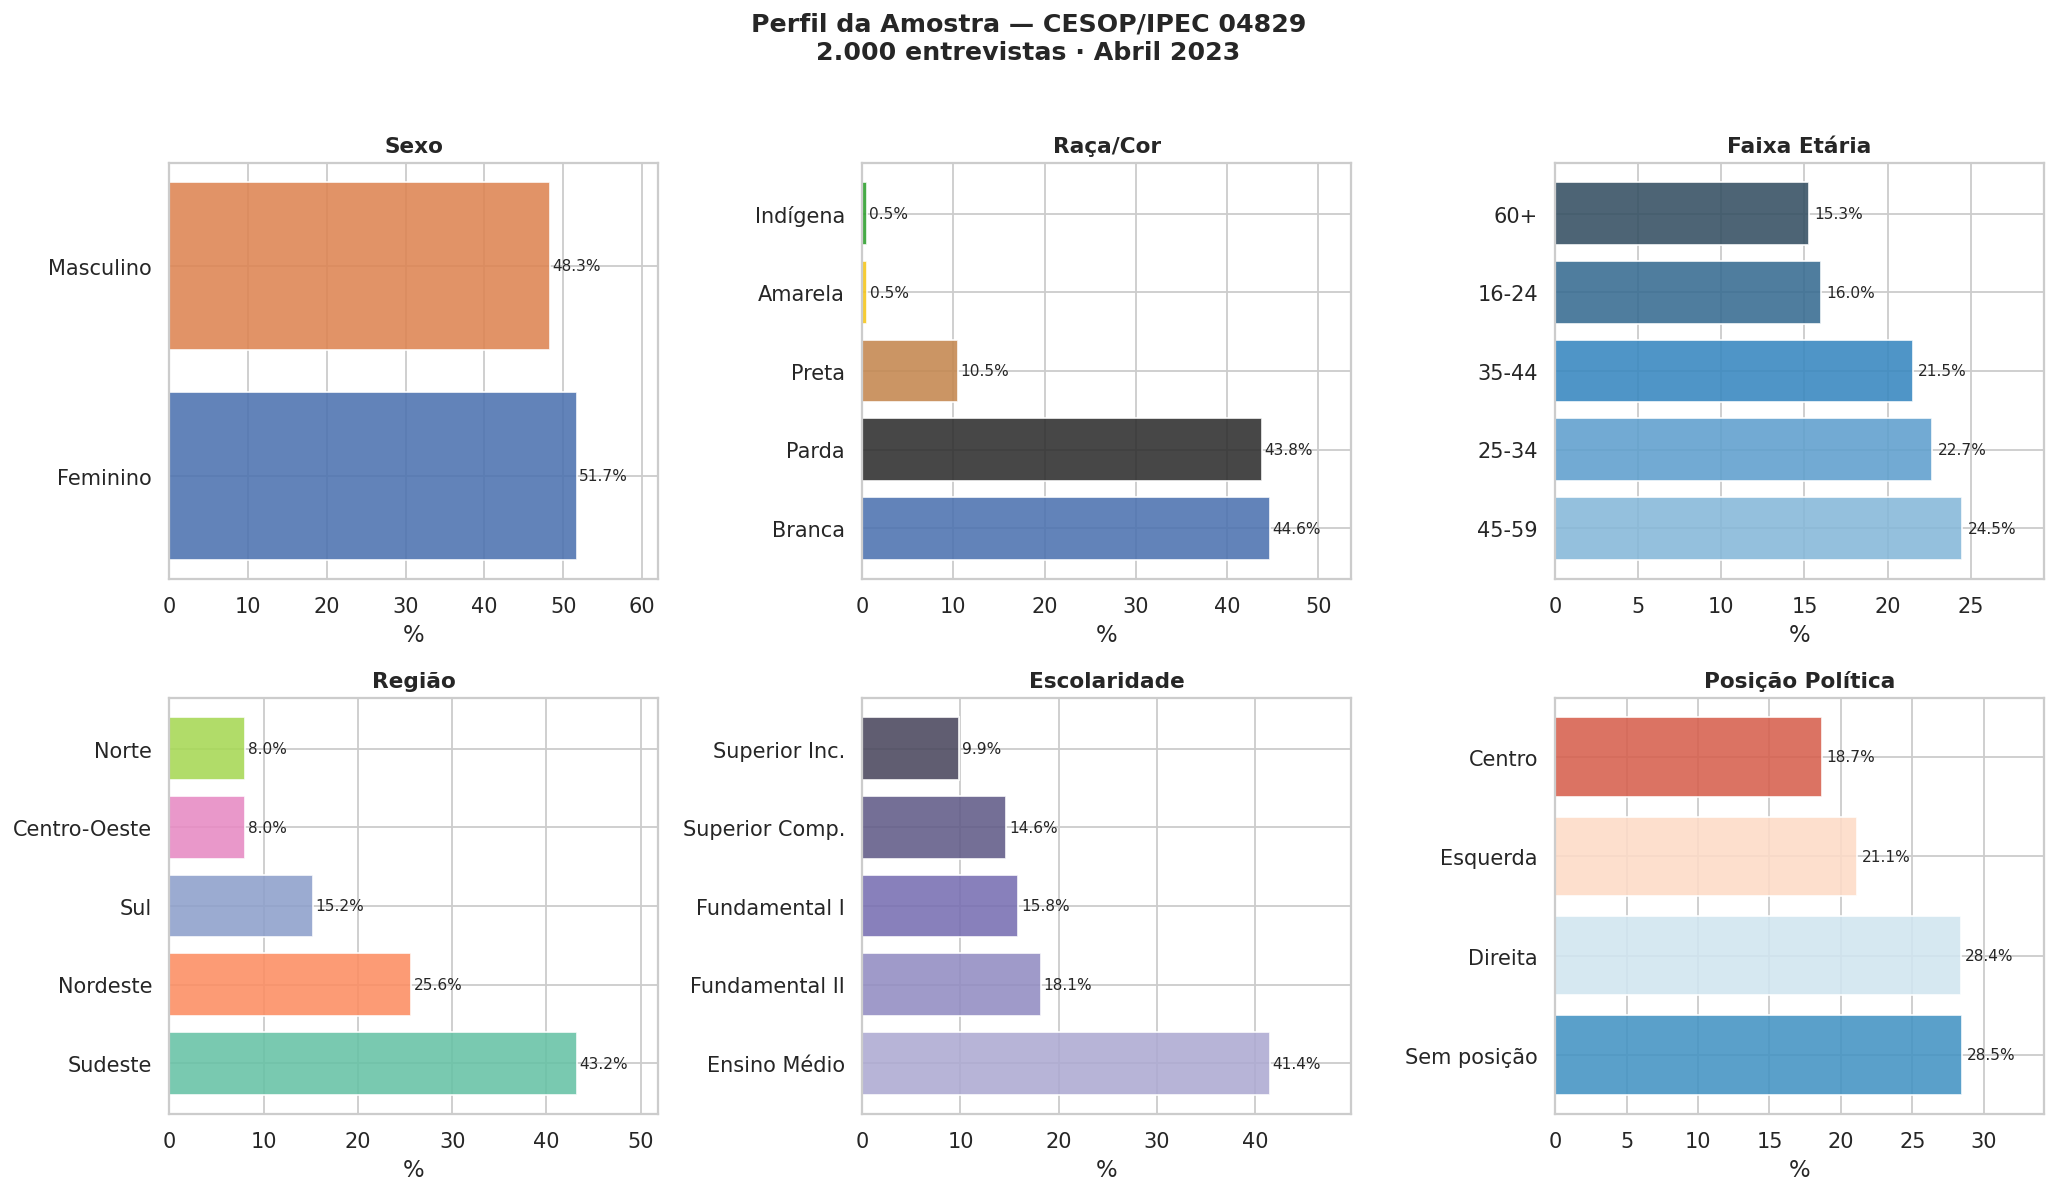

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Perfil da Amostra — CESOP/IPEC 04829\n2.000 entrevistas · Abril 2023',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (col, titulo, cores) in zip(axes.flat, [
    ('sexo_label','Sexo',['#4C72B0','#DD8452']),
    ('raca_label','Raça/Cor',list(COR_RACA.values())),
    ('fxidade_label','Faixa Etária',sns.color_palette('Blues_d',5)),
    ('regiao_label','Região',sns.color_palette('Set2',5)),
    ('escol_grupo','Escolaridade',sns.color_palette('Purples_d',5)),
    ('politica_label','Posição Política',sns.color_palette('RdBu_r',4)),
]):
    cnt = df[col].value_counts(dropna=True)
    pct = cnt.values / len(df) * 100
    bars = ax.barh(cnt.index, pct, color=cores[:len(cnt)], alpha=0.88)
    ax.set_title(titulo)
    ax.set_xlabel('%')
    for bar, val in zip(bars, pct):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5)
    ax.set_xlim(0, max(pct)*1.2)

plt.tight_layout()
plt.savefig('fig_01_perfil_amostra.png', bbox_inches='tight')
plt.show()

---
## 3. Análise 1 — Paradoxo da Consciência Racial <a id='3'></a>

> **Hipótese:** Existe gap sistemático entre reconhecer o racismo estrutural  
> ("O Brasil é racista") e assumir responsabilidade individual  
> ("Eu tenho atitudes racistas"). Esse gap varia por raça?

**Índice de Dissonância Cognitiva Racial (IDCR)** = % concorda P5A − % concorda P5C

            Brasil é racista  Tenho atitudes racistas  IDCR
raca_label                                                 
Preta                   86.6                     12.9  73.7
Branca                  80.5                      9.8  70.6
Parda                   81.6                     11.8  69.9
Amarela                 81.8                     18.2  63.6
Indígena                90.0                     40.0  50.0


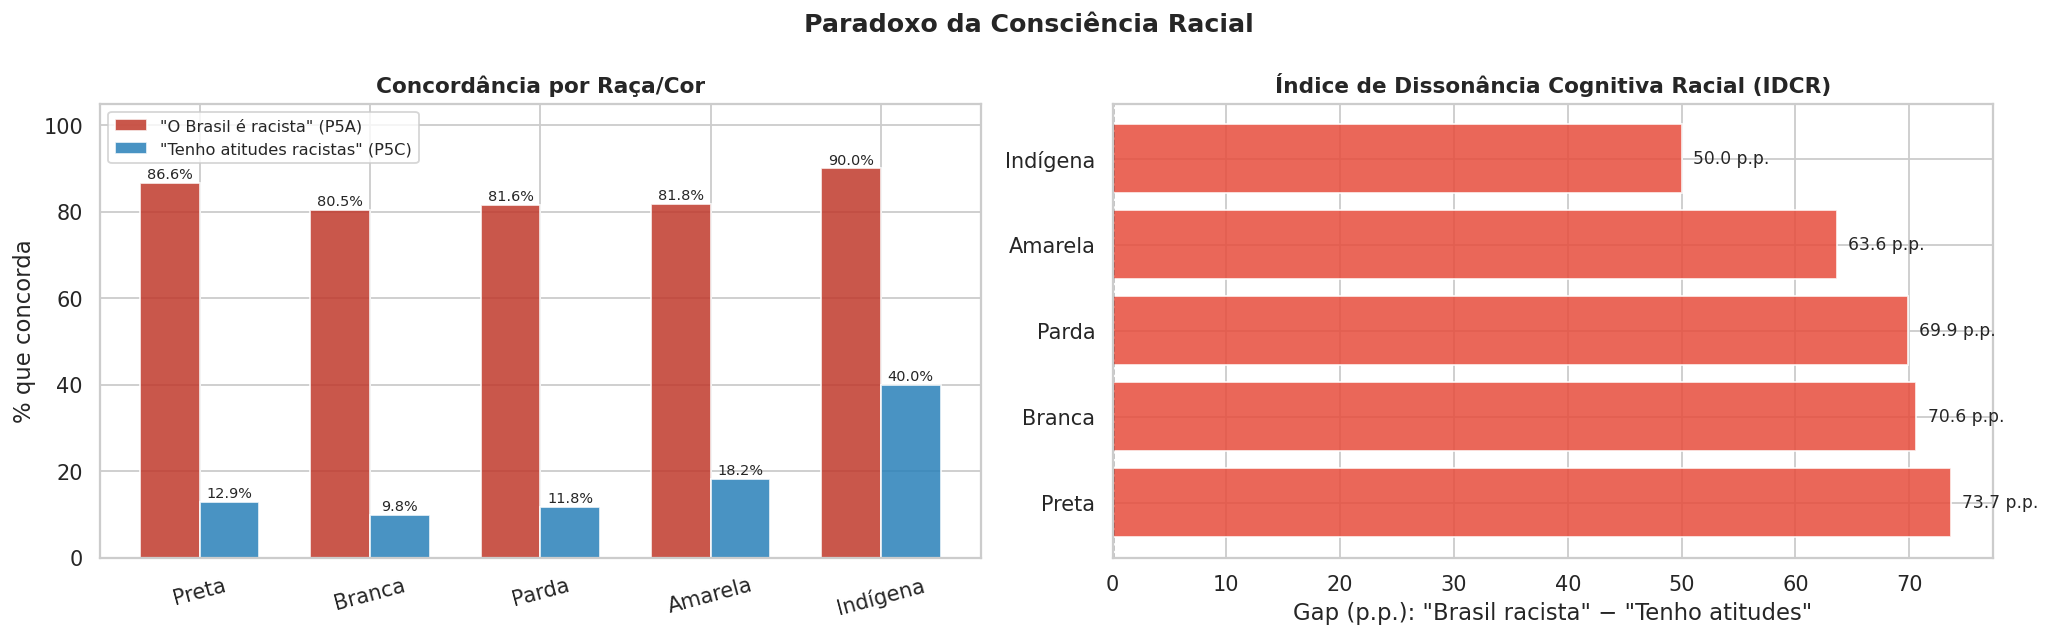


Qui-quadrado (raça × atitudes racistas): χ²=11.44, p=0.0220
→ Diferença SIGNIFICATIVA (α=0.05)


In [6]:
taxa = df.groupby('raca_label')[['P5A_bin','P5C_bin']].mean() * 100
taxa.columns = ['Brasil é racista','Tenho atitudes racistas']
taxa['IDCR'] = taxa['Brasil é racista'] - taxa['Tenho atitudes racistas']
taxa = taxa.sort_values('IDCR', ascending=False)
print(taxa.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Paradoxo da Consciência Racial', fontsize=14, fontweight='bold')

ax = axes[0]
x = np.arange(len(taxa)); w = 0.35
b1 = ax.bar(x-w/2, taxa['Brasil é racista'], w,
            label='"O Brasil é racista" (P5A)', color='#c0392b', alpha=0.85)
b2 = ax.bar(x+w/2, taxa['Tenho atitudes racistas'], w,
            label='"Tenho atitudes racistas" (P5C)', color='#2980b9', alpha=0.85)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(taxa.index, rotation=15)
ax.set_ylabel('% que concorda'); ax.legend(fontsize=9); ax.set_ylim(0,105)
ax.set_title('Concordância por Raça/Cor')

ax2 = axes[1]
cores_g = ['#e74c3c' if v>0 else '#3498db' for v in taxa['IDCR']]
bars = ax2.barh(taxa.index, taxa['IDCR'], color=cores_g, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, taxa['IDCR']):
    ax2.text(val+(1 if val>=0 else -1), bar.get_y()+bar.get_height()/2,
             f'{val:.1f} p.p.', va='center', ha='left' if val>=0 else 'right', fontsize=9.5)
ax2.set_xlabel('Gap (p.p.): "Brasil racista" − "Tenho atitudes"')
ax2.set_title('Índice de Dissonância Cognitiva Racial (IDCR)')

plt.tight_layout()
plt.savefig('fig_02_paradoxo.png', bbox_inches='tight')
plt.show()

chi2, p, dof, _ = chi2_contingency(pd.crosstab(df['raca_label'], df['P5C_bin']))
print(f'\nQui-quadrado (raça × atitudes racistas): χ²={chi2:.2f}, p={p:.4f}')
print('→ Diferença', 'SIGNIFICATIVA' if p<0.05 else 'NÃO significativa', '(α=0.05)')

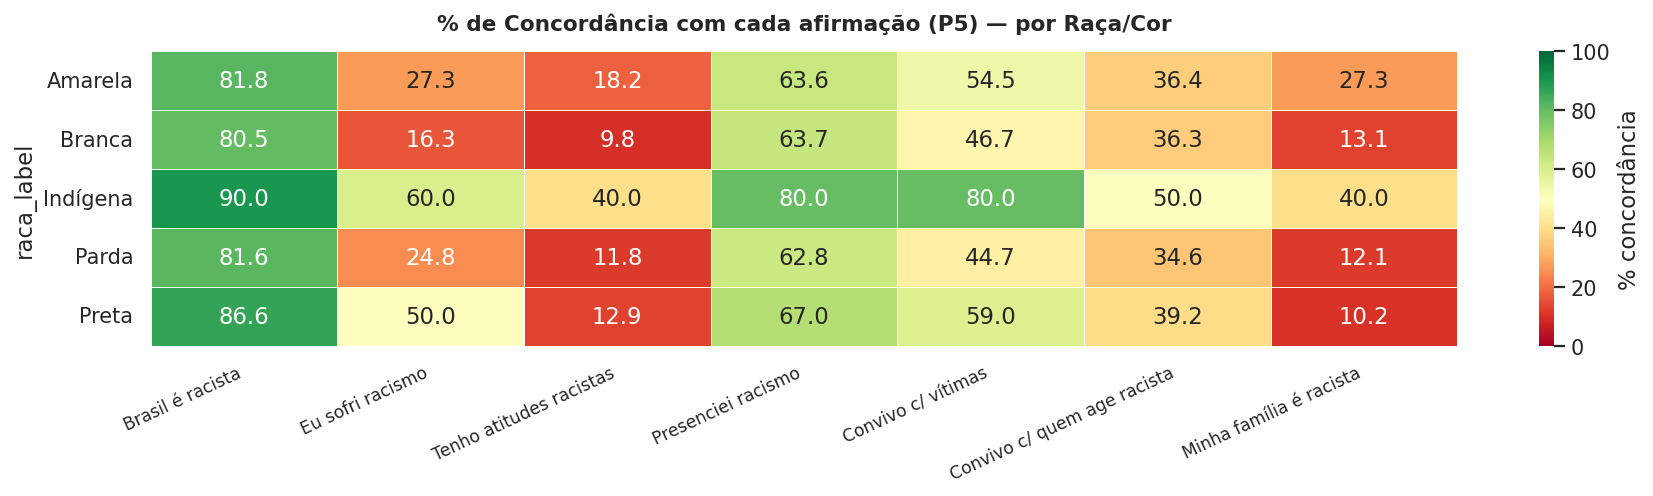

In [7]:
# Heatmap P5 por raça
cols_bin = [c+'_bin' for c in ITENS_P5]
matriz = df.groupby('raca_label')[cols_bin].mean() * 100
matriz.columns = list(ITENS_P5.values())

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(matriz, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            ax=ax, vmin=0, vmax=100, cbar_kws={'label':'% concordância'})
ax.set_title('% de Concordância com cada afirmação (P5) — por Raça/Cor', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9.5)
plt.tight_layout()
plt.savefig('fig_03_heatmap_p5.png', bbox_inches='tight')
plt.show()

---
## 4. Análise 2 — Distância Social do Racismo <a id='4'></a>

> A percepção de racismo declina conforme a afirmação se aproxima da esfera pessoal.  
> A velocidade desse declínio varia entre grupos raciais e regiões?

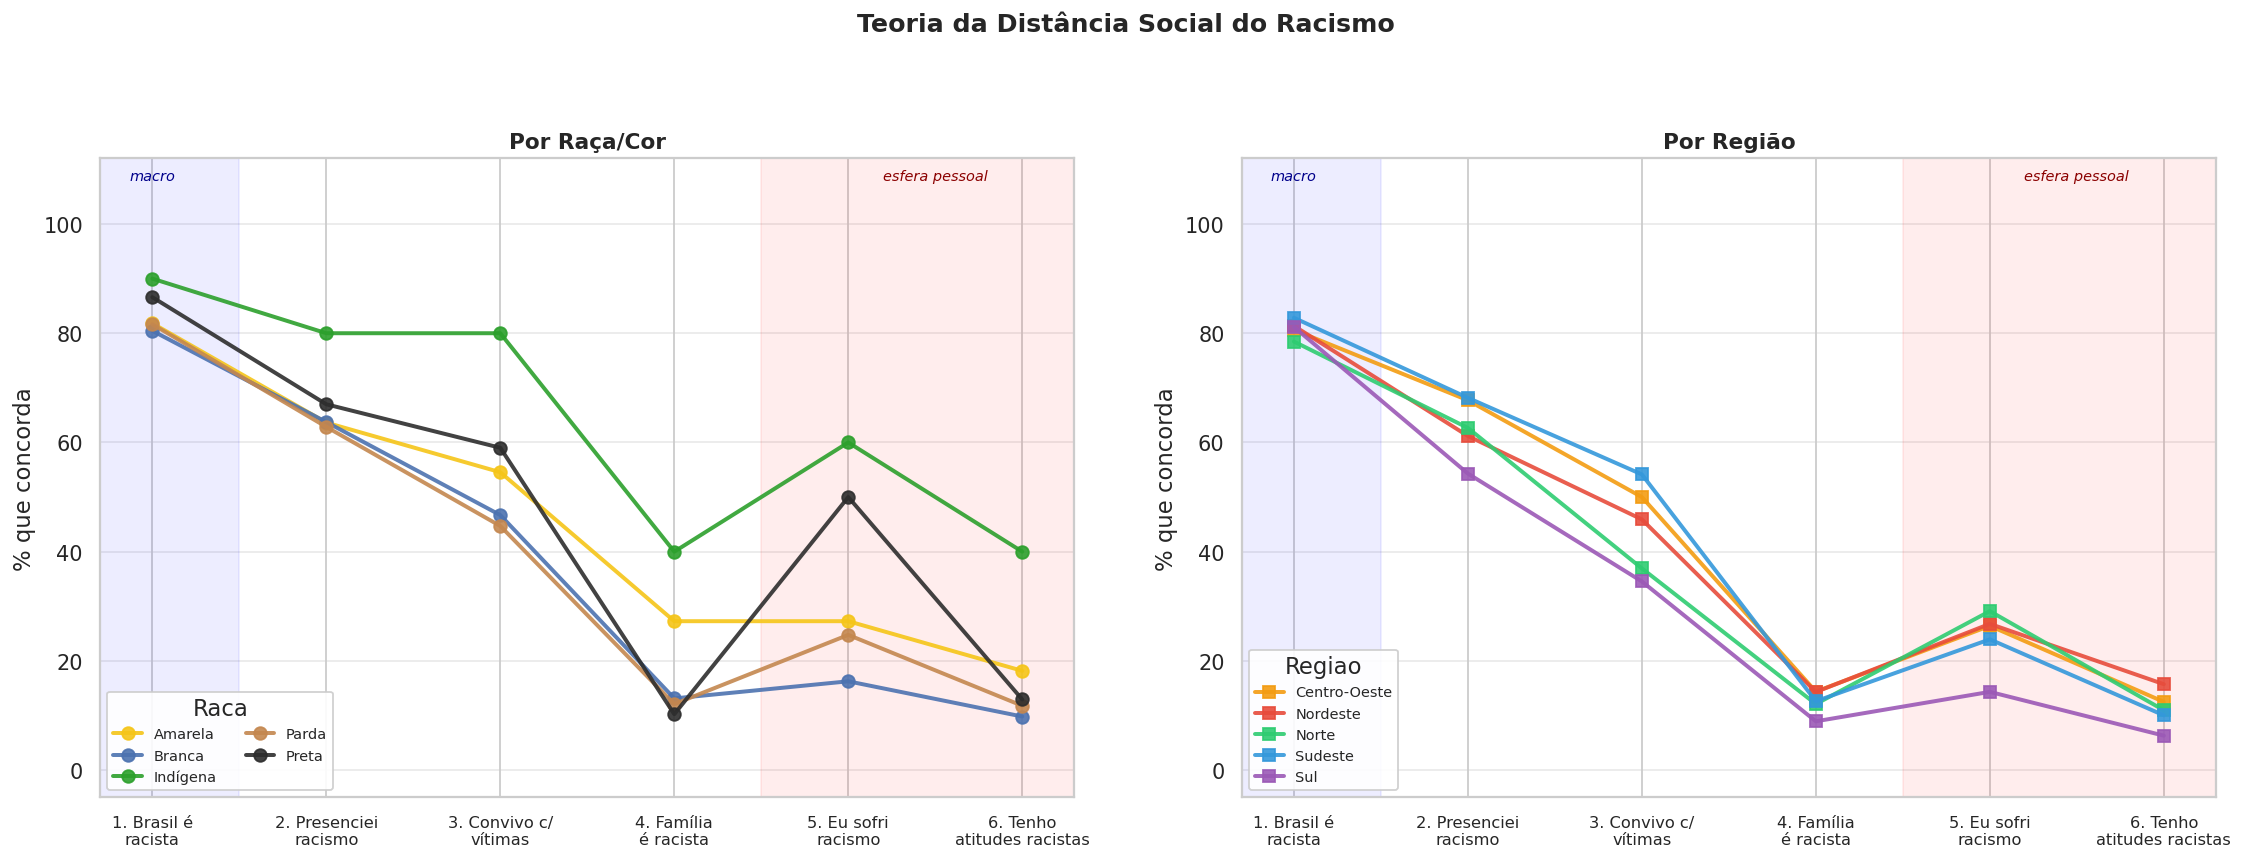

In [8]:
ESCALA = [('P5A_bin','1. Brasil é\nracista'),('P5D_bin','2. Presenciei\nracismo'),
          ('P5G_bin','3. Convivo c/\nvítimas'),('P5I_bin','4. Família\né racista'),
          ('P5B_bin','5. Eu sofri\nracismo'),('P5C_bin','6. Tenho\natitudes racistas')]
cols_e  = [c for c,_ in ESCALA]
labels_e = [l for _,l in ESCALA]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Teoria da Distância Social do Racismo', fontsize=14, fontweight='bold')

for ax, (groupby_col, titulo) in zip(axes, [
        ('raca_label',  'Por Raça/Cor'),
        ('regiao_label','Por Região')]):

    dist = df.groupby(groupby_col)[cols_e].mean() * 100
    dist.columns = labels_e
    palette = COR_RACA if groupby_col == 'raca_label' else COR_REGIAO
    marker  = 'o'       if groupby_col == 'raca_label' else 's'

    for grupo, row in dist.iterrows():
        cor = palette.get(grupo, '#999999')
        ax.plot(range(len(labels_e)), row.values,
                marker=marker, linewidth=2.2, markersize=7,
                color=cor, label=grupo, alpha=0.9)

    ax.set_xticks(range(len(labels_e)))
    ax.set_xticklabels(labels_e, ha='center', fontsize=9)
    ax.set_ylabel('% que concorda')
    ax.set_title(titulo)
    ax.set_ylim(-5, 112)
    ax.set_xlim(-0.3, len(labels_e) - 0.7)
    ax.axvspan(3.5, 5.5, alpha=0.07, color='red')
    ax.axvspan(-0.3, 0.5, alpha=0.07, color='blue')
    ax.text(4.5, 108, 'esfera pessoal', ha='center', fontsize=8,
            color='darkred', style='italic')
    ax.text(0, 108, 'macro', ha='center', fontsize=8,
            color='darkblue', style='italic')
    ax.grid(axis='y', alpha=0.4)
    # Legenda no canto inferior esquerdo, sem sobrepor linhas
    ax.legend(title=groupby_col.replace('_label','').capitalize(),
              loc='lower left', fontsize=8, framealpha=0.9,
              ncol=2 if groupby_col=='raca_label' else 1)

plt.tight_layout(pad=2.5)
plt.savefig('fig_04_distancia_social.png', bbox_inches='tight')
plt.show()


---
## 5. Análise 3 — Anatomia do Apoio às Cotas <a id='5'></a>

> A hierarquia de apoio (PcD > Social > Racial > Mulheres > LGBTQIA+) revela algo  
> sobre o caráter do apoio à inclusão no Brasil?

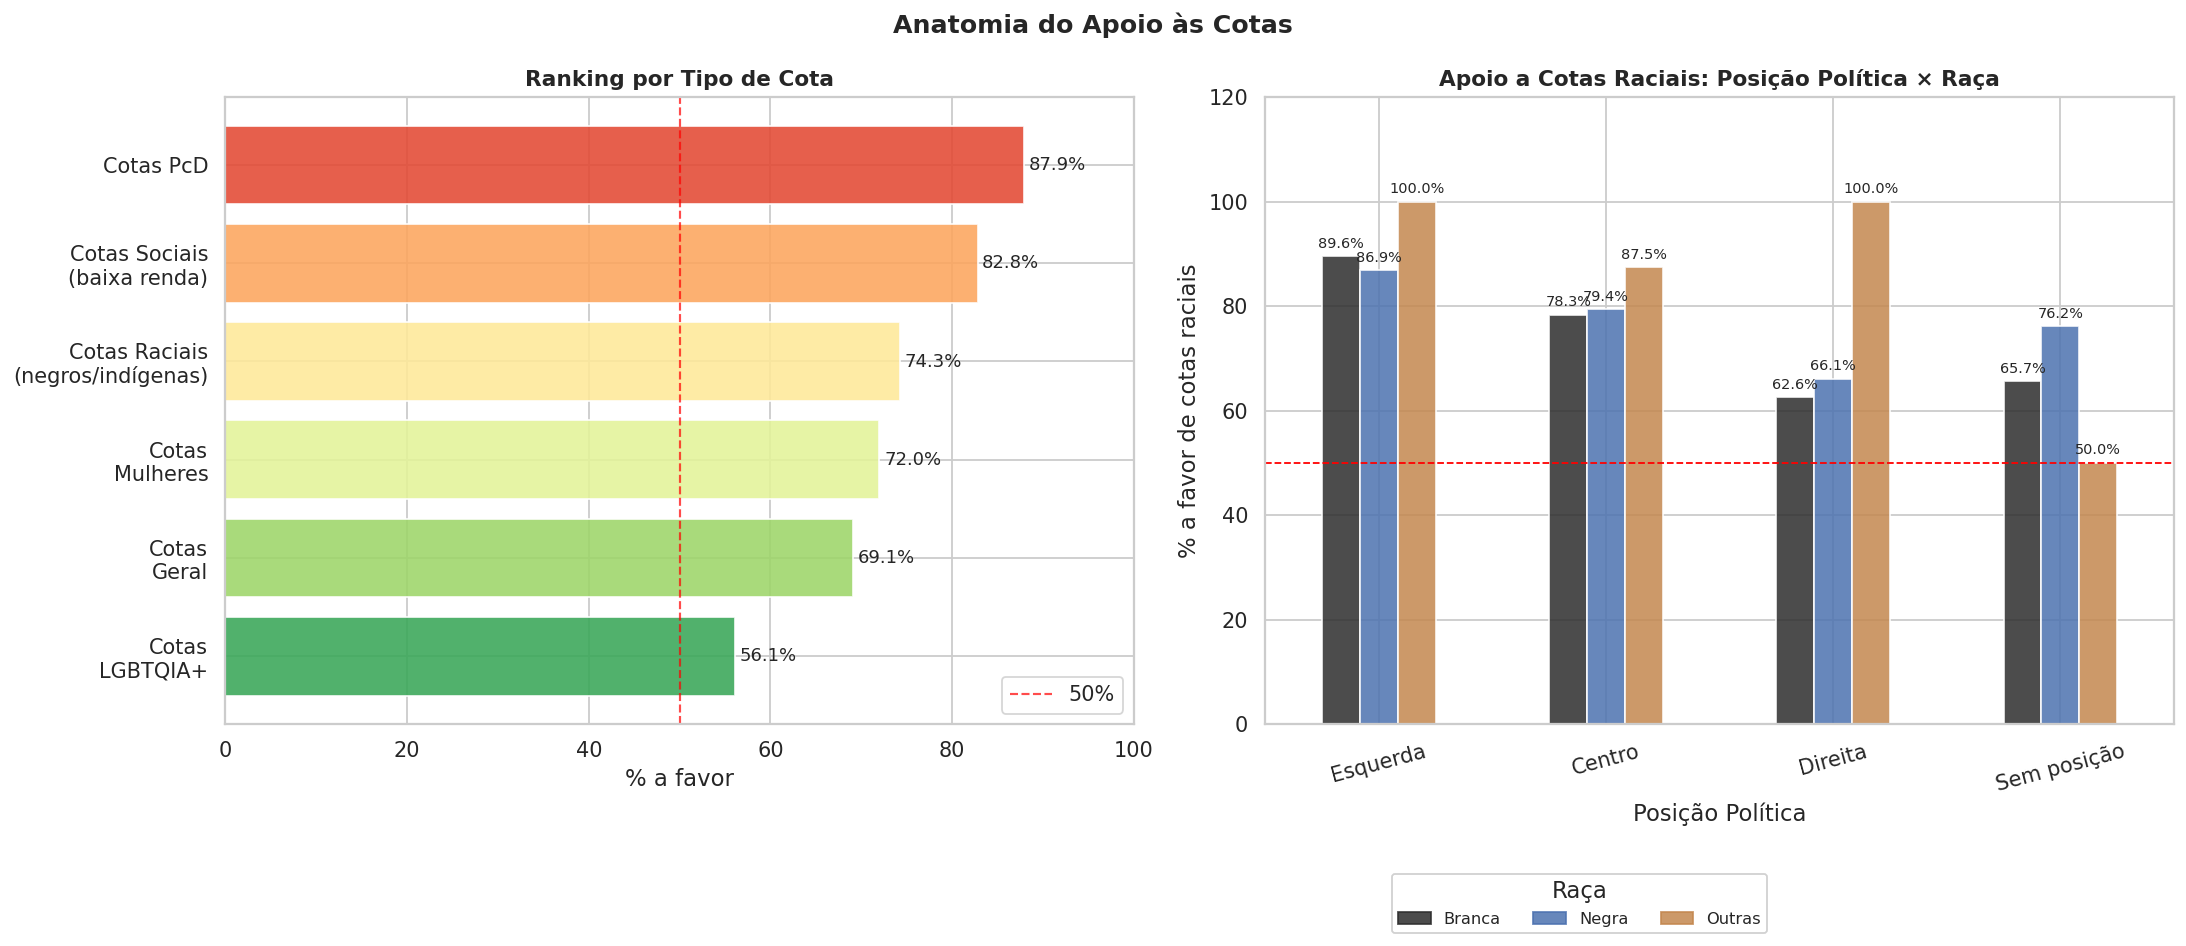

In [9]:
COTAS = {'P21A':'Cotas\nGeral',
          'P21B':'Cotas Raciais\n(negros/indígenas)',
          'P21C':'Cotas Sociais\n(baixa renda)',
          'P21D':'Cotas PcD',
          'P21E':'Cotas\nMulheres',
          'P21F':'Cotas\nLGBTQIA+'}

favor = {label: (df[col]==1).sum()/df[col].notna().sum()*100
         for col, label in COTAS.items()}
favor_s = pd.Series(favor).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Anatomia do Apoio às Cotas', fontsize=14, fontweight='bold')

# --- Painel esq: ranking ---
bars = axes[0].barh(favor_s.index, favor_s.values,
                    color=sns.color_palette('RdYlGn', len(favor_s))[::-1], alpha=0.88)
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.2,
                alpha=0.7, label='50%')
for bar, val in zip(bars, favor_s.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('% a favor')
axes[0].set_title('Ranking por Tipo de Cota')
axes[0].set_xlim(0, 100)
axes[0].legend(loc='lower right')

# --- Painel dir: política × raça ---
pivot = (df[df['politica_label'].notna() & df['raca_grupo'].notna()]
         .groupby(['politica_label','raca_grupo'])
         .apply(lambda g: (g['P21B']==1).sum() / g['P21B'].notna().sum() * 100)
         .unstack())
pivot = pivot.reindex(
    [p for p in ['Esquerda','Centro','Direita','Sem posição'] if p in pivot.index])

ax2 = axes[1]
bars_plot = pivot.plot(kind='bar', ax=ax2, alpha=0.85,
                       color=['#2d2d2d','#4C72B0','#C4874F'],
                       legend=False)   # desativar legenda automática

ax2.set_ylim(0, 120)
ax2.set_title('Apoio a Cotas Raciais: Posição Política × Raça')
ax2.set_xlabel('Posição Política')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15)
ax2.axhline(50, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('% a favor de cotas raciais')

for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%', fontsize=8, padding=3)

# Legenda FORA da figura — abaixo dos dois subplots, sem tocar em nenhum
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85)
           for c in ['#2d2d2d','#4C72B0','#C4874F']]
labels  = [str(col) for col in pivot.columns]
fig.legend(handles, labels, title='Raça',
           loc='lower center',
           bbox_to_anchor=(0.72, -0.04),   # centralizado sob o painel direito
           ncol=3, fontsize=9, framealpha=0.9)

plt.tight_layout(rect=[0, 0.06, 1, 1])    # reserva 6% embaixo para a legenda
plt.savefig('fig_05_cotas.png', bbox_inches='tight')
plt.show()


---
## 6. Análise 4 — Motor das Desigualdades: Raça ou Classe? <a id='6'></a>

> Respondentes de maior renda preferem "classe social" a "raça/cor" para explicar  
> desigualdades — evidência de mascaramento da desigualdade racial?

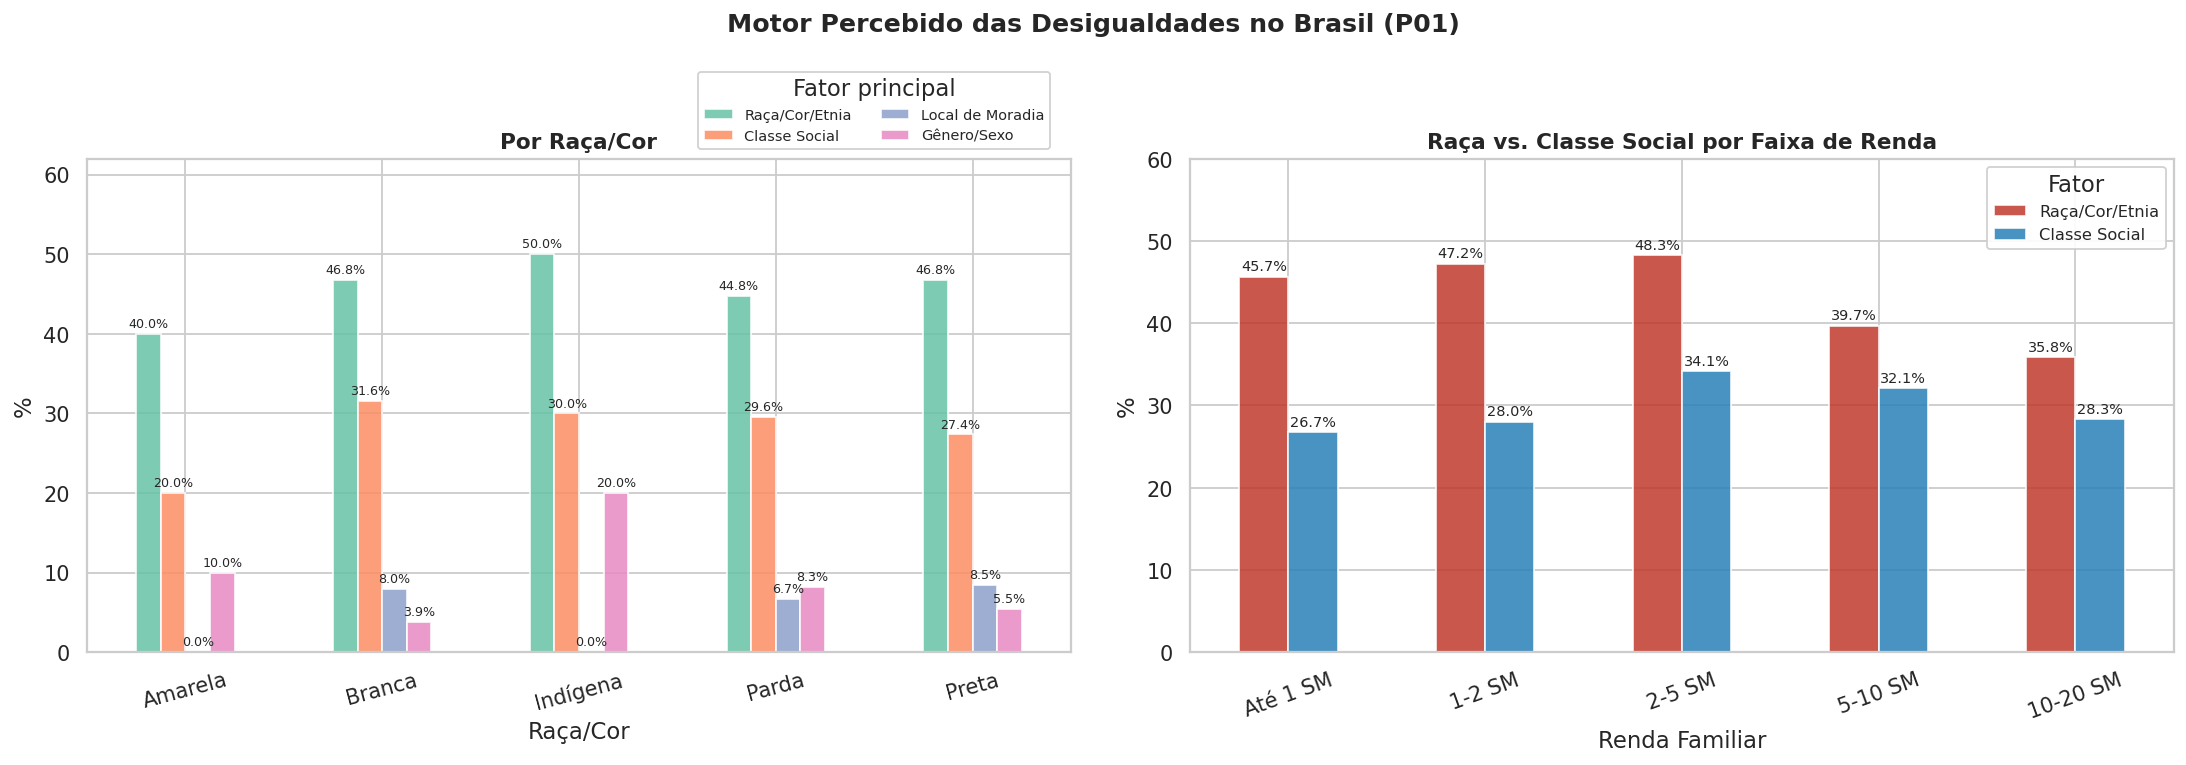

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Motor Percebido das Desigualdades no Brasil (P01)',
             fontsize=14, fontweight='bold')

top4 = ['Raça/Cor/Etnia','Classe Social','Local de Moradia','Gênero/Sexo']

# Painel esq: por raça
ct_raca = pd.crosstab(df['raca_label'], df['p1_label'], normalize='index') * 100
ct_raca[[c for c in top4 if c in ct_raca.columns]].plot(
    kind='bar', ax=axes[0], alpha=0.85, color=sns.color_palette('Set2', 4))
axes[0].set_title('Por Raça/Cor')   # pad cria espaço para legenda acima
axes[0].set_xlabel('Raça/Cor')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 62)
# Legenda acima do subplot, fora da área de dados
axes[0].legend(title='Fator principal', fontsize=8,
               loc='lower center',
               bbox_to_anchor=(0.8, 1.02),
               ncol=2, framealpha=0.9, borderaxespad=0)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', fontsize=7, padding=2)

# Painel dir: raça vs classe por renda
ct_renda = pd.crosstab(df['renda_label'], df['p1_label'], normalize='index') * 100
ct_renda_plot = ct_renda[
    [c for c in ['Raça/Cor/Etnia','Classe Social'] if c in ct_renda.columns]]
ct_renda_plot = ct_renda_plot.reindex(
    [r for r in ORDEM_RENDA if r in ct_renda_plot.index])
ct_renda_plot.plot(kind='bar', ax=axes[1], alpha=0.85,
                   color=['#c0392b','#2980b9'])
axes[1].set_title('Raça vs. Classe Social por Faixa de Renda')
axes[1].set_xlabel('Renda Familiar')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 60)
axes[1].legend(title='Fator', fontsize=9, loc='upper right', framealpha=0.9)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('fig_06_motor_desigualdades.png', bbox_inches='tight')
plt.show()


---
## 7. Análise 5 — Definição Popular de Racismo <a id='7'></a>

> P7 é resposta múltipla **cascateada**: o respondente escolhe opções em sequência.  
> A lógica correta verifica a presença da opção em **todas** as posições (P7_1 a P7_6).

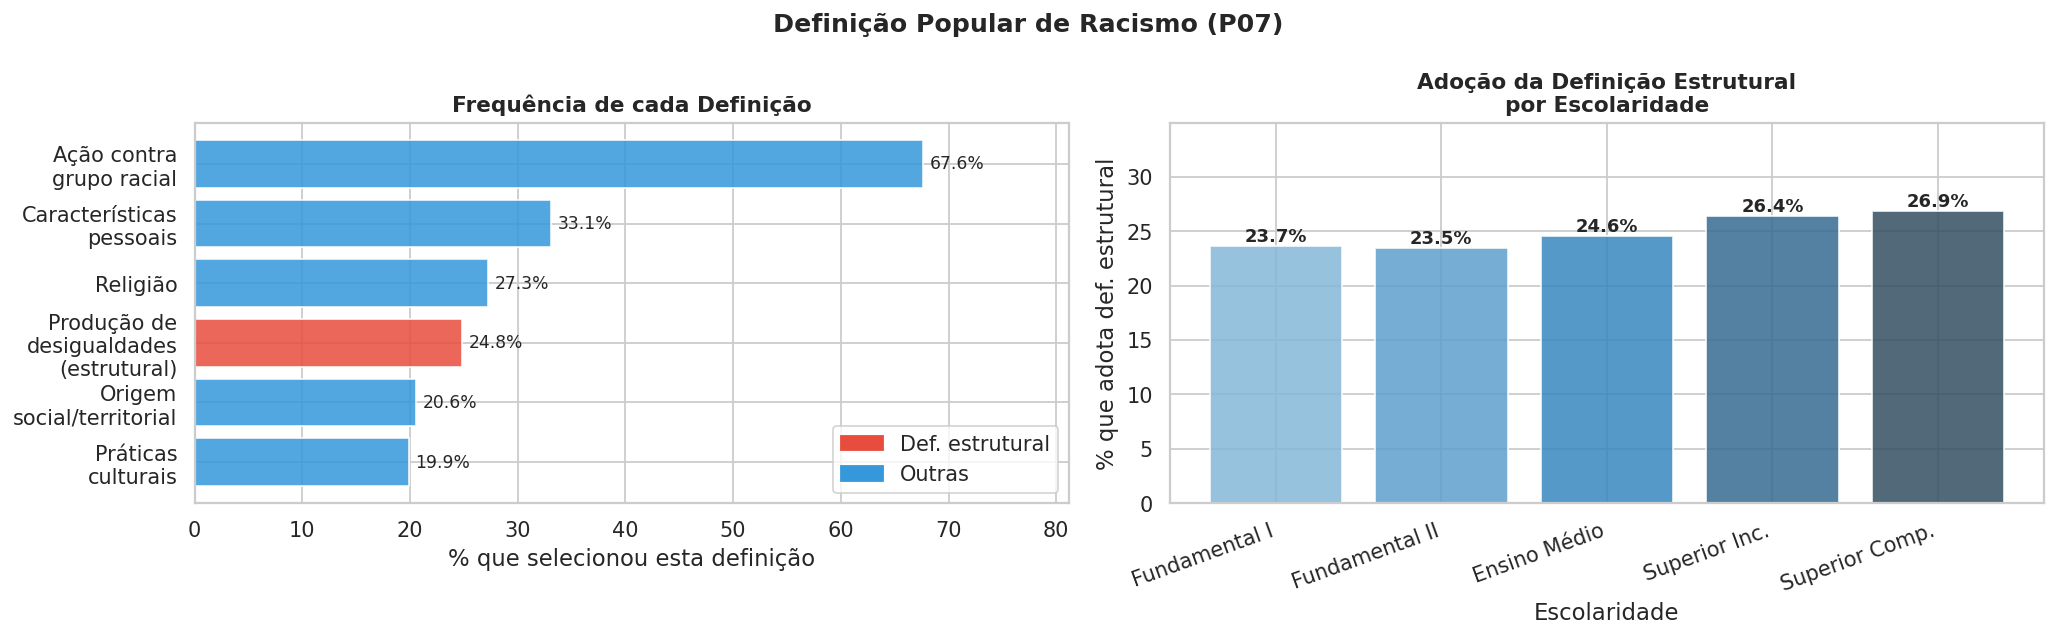

In [11]:
P7_OPCOES = {1:'Ação contra\ngrupo racial',2:'Origem\nsocial/territorial',
              3:'Práticas\nculturais',4:'Religião',
              5:'Características\npessoais',6:'Produção de\ndesigualdades\n(estrutural)'}

validos = df['P7_1'] != 99
taxa_p7 = {label: escolheu_rm(df[validos], op, 'P7', 6).mean()*100
           for op, label in P7_OPCOES.items()}
taxa_p7_s = pd.Series(taxa_p7).sort_values(ascending=True)

df['escolheu_estrutural'] = escolheu_rm(df, 6, 'P7', 6).astype(float)
df.loc[df['P7_1']==99, 'escolheu_estrutural'] = np.nan

taxa_escol = (df.groupby('escol_grupo')['escolheu_estrutural'].mean() * 100).reindex(
    [e for e in ORDEM_ESCOL if e in df['escol_grupo'].unique()]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Definição Popular de Racismo (P07)', fontsize=14, fontweight='bold')

cores = ['#e74c3c' if 'estrutural' in l else '#3498db' for l in taxa_p7_s.index]
bars = axes[0].barh(taxa_p7_s.index, taxa_p7_s.values, color=cores, alpha=0.85)
for bar, val in zip(bars, taxa_p7_s.values):
    axes[0].text(val+0.6, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9.5)
axes[0].set_xlabel('% que selecionou esta definição')
axes[0].set_title('Frequência de cada Definição')
axes[0].set_xlim(0, max(taxa_p7_s.values)*1.2)
axes[0].legend(handles=[mpatches.Patch(color='#e74c3c',label='Def. estrutural'),
                          mpatches.Patch(color='#3498db',label='Outras')])

escol_plot = [e for e in ORDEM_ESCOL if e in taxa_escol.index]
bars2 = axes[1].bar(escol_plot, taxa_escol.reindex(escol_plot).values,
                     color=sns.color_palette('Blues_d',len(escol_plot)), alpha=0.85)
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        axes[1].text(bar.get_x()+bar.get_width()/2, h+0.4,
                     f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Escolaridade'); axes[1].set_ylabel('% que adota def. estrutural')
axes[1].set_title('Adoção da Definição Estrutural\npor Escolaridade')
axes[1].set_xticklabels(escol_plot, rotation=20, ha='right')
axes[1].set_ylim(0, max(taxa_escol.values)*1.3)

plt.tight_layout()
plt.savefig('fig_07_definicao_racismo.png', bbox_inches='tight')
plt.show()

---
## 8. Análise 6 — Percepção do Racismo Policial <a id='8'></a>

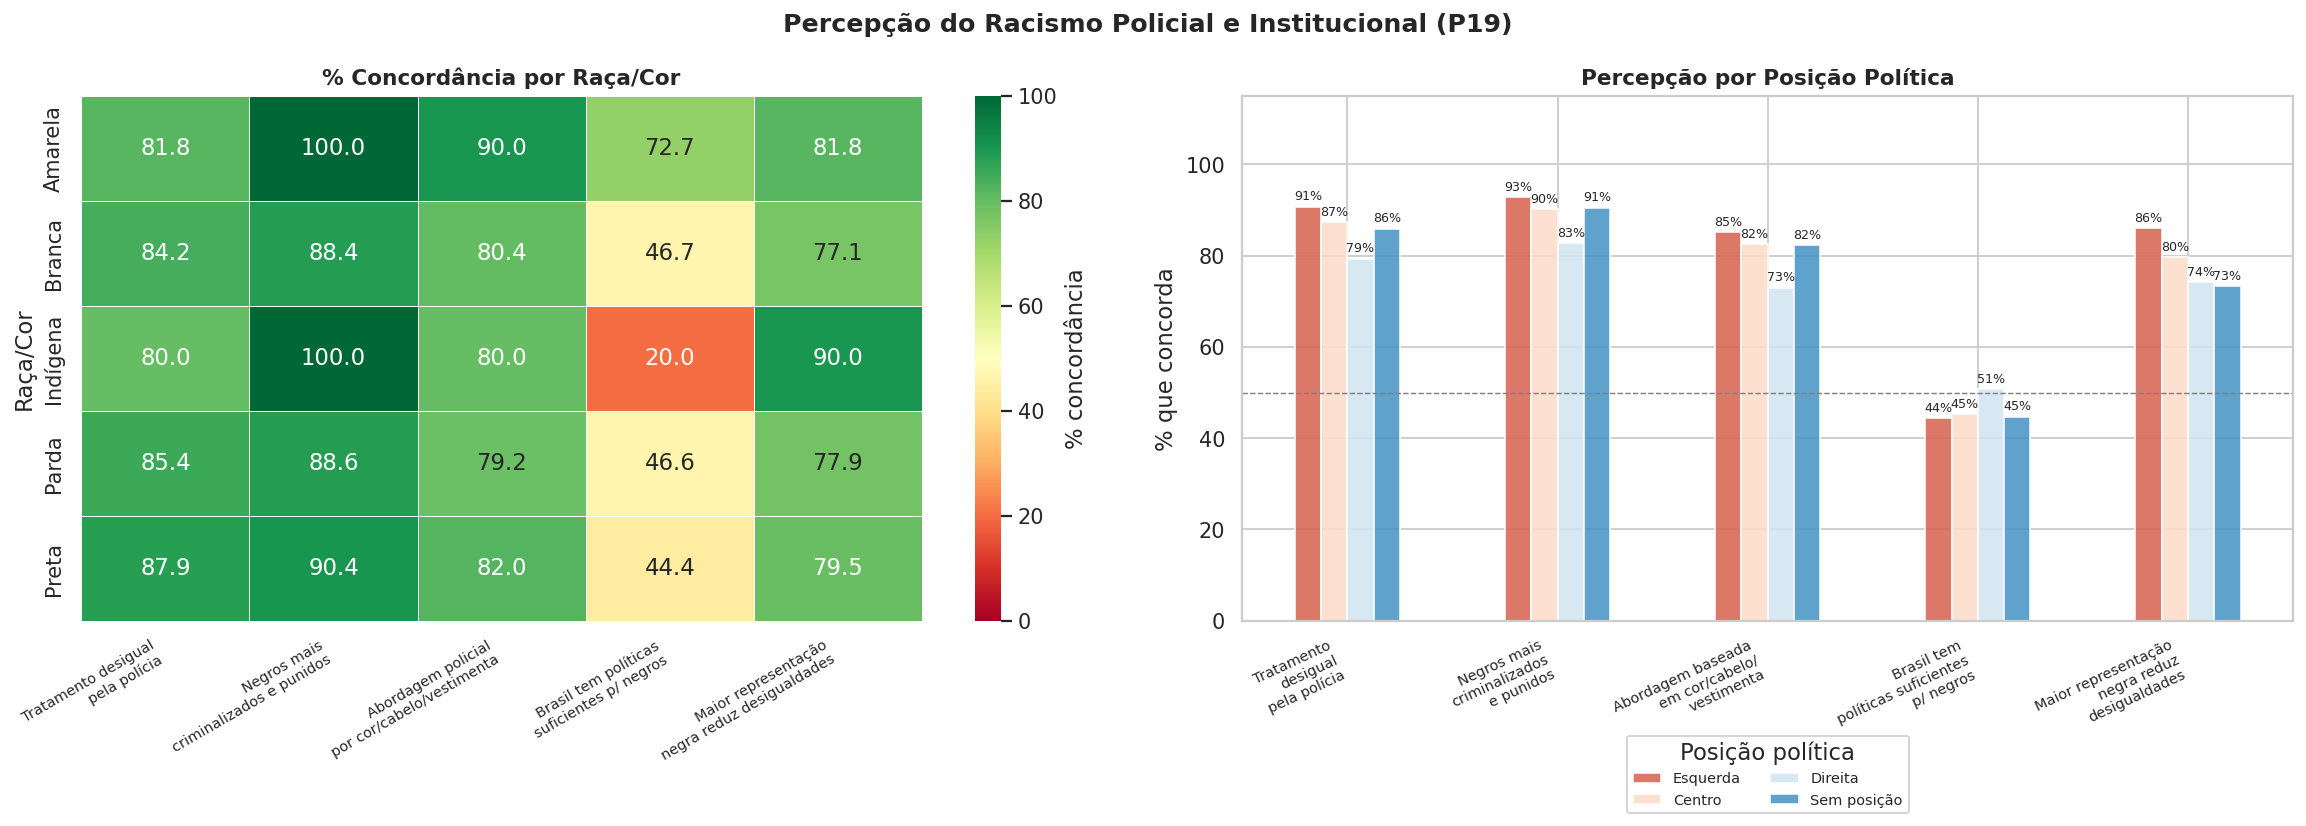

In [12]:
P19_LABELS_CURTOS = {
    'P19A': 'Tratamento\ndesigual\npela polícia',
    'P19B': 'Negros mais\ncriminalizados\ne punidos',
    'P19C': 'Abordagem baseada\nem cor/cabelo/\nvestimenta',
    'P19D': 'Brasil tem\npolíticas suficientes\np/ negros',
    'P19E': 'Maior representação\nnegra reduz\ndesigualdades',
}
P19_LABELS_HEATMAP = {
    'P19A': 'Tratamento desigual\npela polícia',
    'P19B': 'Negros mais\ncriminalizados e punidos',
    'P19C': 'Abordagem policial\npor cor/cabelo/vestimenta',
    'P19D': 'Brasil tem políticas\nsuficientes p/ negros',
    'P19E': 'Maior representação\nnegra reduz desigualdades',
}

for col in P19_LABELS_CURTOS:
    df[col+'_bin'] = df[col].apply(
        lambda x: 1 if x in [1,2] else (np.nan if x in [98,99] else 0))

taxa_p19_raca = df.groupby('raca_label')[
    [c+'_bin' for c in P19_LABELS_CURTOS]].mean() * 100
taxa_p19_raca.columns = list(P19_LABELS_HEATMAP.values())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Percepção do Racismo Policial e Institucional (P19)',
             fontsize=14, fontweight='bold')

# Heatmap
sns.heatmap(taxa_p19_raca, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={'label': '% concordância'})
axes[0].set_title('% Concordância por Raça/Cor')
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Raça/Cor')

# Barras por posição política
taxa_p19_pol = df.groupby('politica_label')[
    [c+'_bin' for c in P19_LABELS_CURTOS]].mean() * 100
taxa_p19_pol.columns = list(P19_LABELS_CURTOS.values())
taxa_p19_pol = taxa_p19_pol.reindex(
    [p for p in ['Esquerda','Centro','Direita','Sem posição']
     if p in taxa_p19_pol.index])

taxa_p19_pol.T.plot(kind='bar', ax=axes[1], alpha=0.85,
                    color=sns.color_palette('RdBu', 4))
axes[1].set_title('Percepção por Posição Política')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=25, ha='right', fontsize=8)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('% que concorda')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8)
# Legenda abaixo do subplot direito, sem sobreposição
axes[1].legend(title='Posição política', fontsize=8,
               loc='lower center',
               bbox_to_anchor=(0.5, -0.38),
               ncol=2, framealpha=0.9)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.0f%%', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('fig_08_racismo_policial.png', bbox_inches='tight')
plt.show()


---
## 9. Correlação Externa 1 — PNAD 2023: Desigualdade Salarial por Raça <a id='9'></a>

> **Fonte:** IBGE — PNAD Contínua Anual, Tabela 10374 (rendimento mensal real) e  
> Tabela 10372 (horas trabalhadas), por cor/raça e UF — **recorte 2023**.
>
> **Alinhamento temporal:** a pesquisa CESOP é de abril de 2023; usamos exclusivamente  
> dados anuais de 2023 do IBGE para garantir comparabilidade.
>
> **Achado central:** não há correlação significativa entre o gap salarial real e  
> a percepção de racismo por UF — o que é em si um resultado analítico importante  
> (normalização da desigualdade racial).

In [13]:
# ============================================================
# LEITURA DAS TABELAS PNAD (SIDRA — formato multi-header)
# ============================================================
def parse_sidra(fname, encoding='utf-8-sig', sep=';'):
    with open(fname, encoding=encoding) as f:
        lines = f.readlines()
    anos_raw  = [x.strip().strip('"') for x in lines[3].split(sep)]
    racas_raw = [x.strip().strip('"') for x in lines[4].split(sep)]
    dados_raw = []
    for line in lines[5:]:
        if 'Fonte:' in line or line.strip() in ['','""']: break
        parts = [p.strip().strip('"').replace(',','.') for p in line.split(sep)]
        if parts and parts[0].strip(): dados_raw.append(parts)
    if not dados_raw: return pd.DataFrame()
    n = len(dados_raw[0])
    ano_atual = ''; col_names = []
    for i in range(n):
        a = anos_raw[i] if i < len(anos_raw) else ''
        r = racas_raw[i] if i < len(racas_raw) else ''
        if a.strip() and a.strip()[0].isdigit(): ano_atual = a.strip()
        col_names.append(f'{ano_atual}_{r.strip()}' if i > 0 else 'local')
    df_o = pd.DataFrame(dados_raw, columns=col_names)
    for c in col_names[1:]: df_o[c] = pd.to_numeric(df_o[c], errors='coerce')
    return df_o

df_rend = parse_sidra('dados_externos/tabela10374.csv')
df_horas = parse_sidra('dados_externos/tabela10372.csv')

# Filtrar UFs e calcular métricas de 2023
df_uf_rend = df_rend[df_rend['local'].isin(MAPA_NOME_SIGLA.keys())].copy()
df_uf_rend['uf_sigla'] = df_uf_rend['local'].map(MAPA_NOME_SIGLA)
df_uf_rend['rend_branca'] = df_uf_rend['2023_Branca']
df_uf_rend['rend_preta']  = df_uf_rend['2023_Preta']
df_uf_rend['rend_parda']  = df_uf_rend['2023_Parda']
df_uf_rend['gap_rend_%']  = ((df_uf_rend['2023_Branca'] / df_uf_rend['2023_Preta']) - 1) * 100

df_uf_h = df_horas[df_horas['local'].isin(MAPA_NOME_SIGLA.keys())].copy()
df_uf_h['uf_sigla'] = df_uf_h['local'].map(MAPA_NOME_SIGLA)

# Rendimento por hora (gap ainda maior que gap de salário bruto)
df_uf_rend = df_uf_rend.merge(
    df_uf_h[['uf_sigla','2023_Branca','2023_Preta']].rename(
        columns={'2023_Branca':'h_branca','2023_Preta':'h_preta'}), on='uf_sigla', how='left')
df_uf_rend['rph_branca'] = df_uf_rend['rend_branca'] / (df_uf_rend['h_branca'] * 4.33)
df_uf_rend['rph_preta']  = df_uf_rend['rend_preta']  / (df_uf_rend['h_preta']  * 4.33)
df_uf_rend['gap_rph_%']  = ((df_uf_rend['rph_branca'] / df_uf_rend['rph_preta']) - 1) * 100

# Percepções CESOP por UF
if 'P21B_bin' not in df.columns:
    if 'P21B' in df.columns:
        df['P21B_bin'] = df['P21B'].apply(lambda x: 1 if x in [1, 2] else (np.nan if x in [98, 99] else 0))
    else:
        df['P21B_bin'] = np.nan

perc_uf = (df.groupby('uf_sigla')[['P5A_bin', 'P19B_bin', 'P21B_bin']].mean() * 100).reset_index()
perc_uf.columns = ['uf_sigla','perc_brasil_racista','perc_negros_criminalizados','perc_favor_cotas']

# Dataset final: apenas UFs com dados em ambas as fontes
df_merge = df_uf_rend[['uf_sigla','rend_branca','rend_preta','gap_rend_%','gap_rph_%']].merge(
    perc_uf, on='uf_sigla').dropna()
df_merge['regiao'] = df_merge['uf_sigla'].map(MAPA_REGIAO)

print(f'UFs no dataset final: {len(df_merge)}')
print()
print('Gap salarial Branca/Preta 2023 por UF (top 5 e bottom 5):')
print(df_merge[['uf_sigla','rend_branca','rend_preta','gap_rend_%',
                 'perc_brasil_racista']].sort_values('gap_rend_%',ascending=False)
      .to_string(index=False))

UFs no dataset final: 25

Gap salarial Branca/Preta 2023 por UF (top 5 e bottom 5):
uf_sigla  rend_branca  rend_preta  gap_rend_%  perc_brasil_racista
      PB         3769        1498  151.602136            84.375000
      RJ         5134        2499  105.442177            86.931818
      DF         7155        3648   96.134868            68.750000
      AM         3825        2161   77.001388            68.750000
      CE         2815        1609   74.953387            76.923077
      AC         3437        2039   68.563021            68.750000
      GO         4094        2488   64.549839            82.812500
      ES         3917        2405   62.869023            80.645161
      PA         3370        2072   62.644788            78.481013
      PE         2591        1606   61.332503            84.615385
      SP         4642        2881   61.124610            80.089485
      TO         3743        2327   60.850881           100.000000
      PI         3482        2211   57.485301

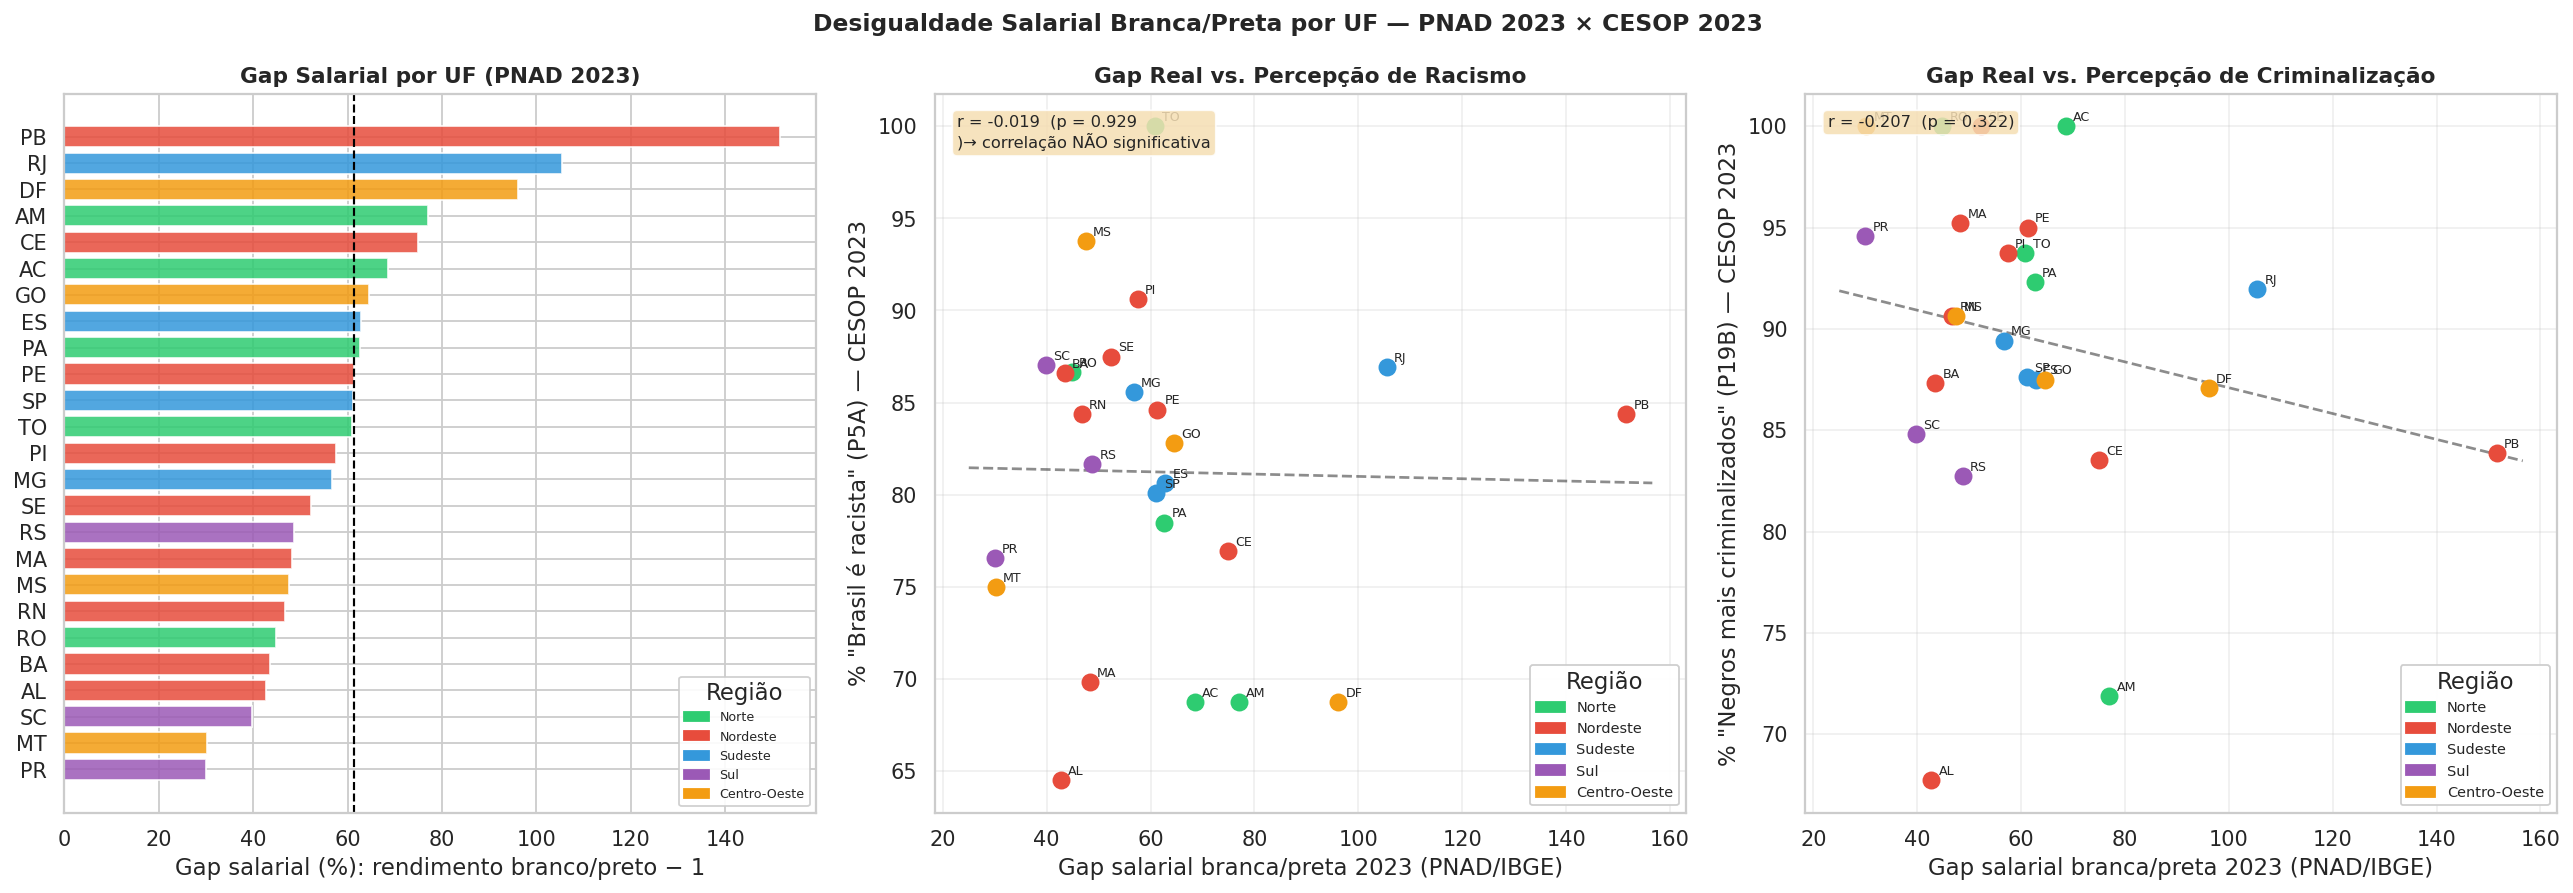


Achado: r=-0.019 (p=0.929) — sem correlação significativa entre gap salarial
e percepção de racismo por UF. Hipótese: normalização/invisibilização da desigualdade.


In [14]:
# Painel PNAD 2023
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Desigualdade Salarial Branca/Preta por UF — PNAD 2023 × CESOP 2023',
             fontsize=13, fontweight='bold')

# ---- Painel 1: gap por UF ----
ax = axes[0]
df_sorted = df_merge.sort_values('gap_rend_%', ascending=True)
cores_uf = [COR_REGIAO.get(r,'#999') for r in df_sorted['regiao']]
ax.barh(df_sorted['uf_sigla'], df_sorted['gap_rend_%'],
        color=cores_uf, alpha=0.85)
ax.axvline(df_merge['gap_rend_%'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f'Média: {df_merge["gap_rend_%"].mean():.1f}%')
ax.set_xlabel('Gap salarial (%): rendimento branco/preto − 1')
ax.set_title('Gap Salarial por UF (PNAD 2023)')
handles_reg = [mpatches.Patch(color=c, label=r) for r, c in COR_REGIAO.items()]
ax.legend(handles=handles_reg, title='Região', fontsize=7, loc='lower right', framealpha=0.9)

# ---- Painel 2 (meio): gap vs percepção de racismo ----
ax2 = axes[1]
for _, row in df_merge.iterrows():
    cor = COR_REGIAO.get(row['regiao'],'#999')
    ax2.scatter(row['gap_rend_%'], row['perc_brasil_racista'],
                color=cor, s=80, zorder=3)
    ax2.annotate(row['uf_sigla'], (row['gap_rend_%'], row['perc_brasil_racista']),
                 textcoords='offset points', xytext=(4,3), fontsize=7)

r1, p1 = pearsonr(df_merge['gap_rend_%'], df_merge['perc_brasil_racista'])
z = np.polyfit(df_merge['gap_rend_%'], df_merge['perc_brasil_racista'], 1)
x_l = np.linspace(df_merge['gap_rend_%'].min()-5,
                   df_merge['gap_rend_%'].max()+5, 100)
ax2.plot(x_l, np.poly1d(z)(x_l), 'k--', alpha=0.5, linewidth=1.5)

# r= no canto SUPERIOR esquerdo (onde não há pontos)
ax2.text(0.03, 0.97,
         f'r = {r1:.3f}  (p = {p1:.3f}\n)→ correlação NÃO significativa',
         transform=ax2.transAxes, fontsize=9, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

# Legenda de regiões no canto INFERIOR esquerdo
# (pontos ficam espalhados no centro/direita, não há estados no canto inf-esq)
handles_r2 = [mpatches.Patch(color=c, label=r) for r, c in COR_REGIAO.items()]
ax2.legend(handles=handles_r2, title='Região', fontsize=8,
           loc='lower right', framealpha=0.95)

ax2.set_xlabel('Gap salarial branca/preta 2023 (PNAD/IBGE)')
ax2.set_ylabel('% "Brasil é racista" (P5A) — CESOP 2023')
ax2.set_title('Gap Real vs. Percepção de Racismo')
ax2.grid(alpha=0.3)

# ---- Painel 3 (dir): gap vs percepção criminalização ----
ax3 = axes[2]
for _, row in df_merge.iterrows():
    cor = COR_REGIAO.get(row['regiao'],'#999')
    ax3.scatter(row['gap_rend_%'], row['perc_negros_criminalizados'],
                color=cor, s=80, zorder=3)
    ax3.annotate(row['uf_sigla'], (row['gap_rend_%'], row['perc_negros_criminalizados']),
                 textcoords='offset points', xytext=(4,3), fontsize=7)

r2, p2 = pearsonr(df_merge['gap_rend_%'], df_merge['perc_negros_criminalizados'])
z2 = np.polyfit(df_merge['gap_rend_%'], df_merge['perc_negros_criminalizados'], 1)
ax3.plot(x_l, np.poly1d(z2)(x_l), 'k--', alpha=0.5, linewidth=1.5)

# r= separado da legenda — canto SUPERIOR esquerdo
ax3.text(0.03, 0.97,
         f'r = {r2:.3f}  (p = {p2:.3f})',
         transform=ax3.transAxes, fontsize=9, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

# Legenda de regiões — canto INFERIOR direito, separada do r=
handles_r3 = [mpatches.Patch(color=c, label=r) for r, c in COR_REGIAO.items()]
ax3.legend(handles=handles_r3, title='Região', fontsize=8,
           loc='lower right', framealpha=0.95)

ax3.set_xlabel('Gap salarial branca/preta 2023 (PNAD/IBGE)')
ax3.set_ylabel('% "Negros mais criminalizados" (P19B) — CESOP 2023')
ax3.set_title('Gap Real vs. Percepção de Criminalização')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_09_pnad_correlacao.png', bbox_inches='tight')
plt.show()

print(f'\nAchado: r={r1:.3f} (p={p1:.3f}) — sem correlação significativa entre gap salarial')
print('e percepção de racismo por UF. Hipótese: normalização/invisibilização da desigualdade.')


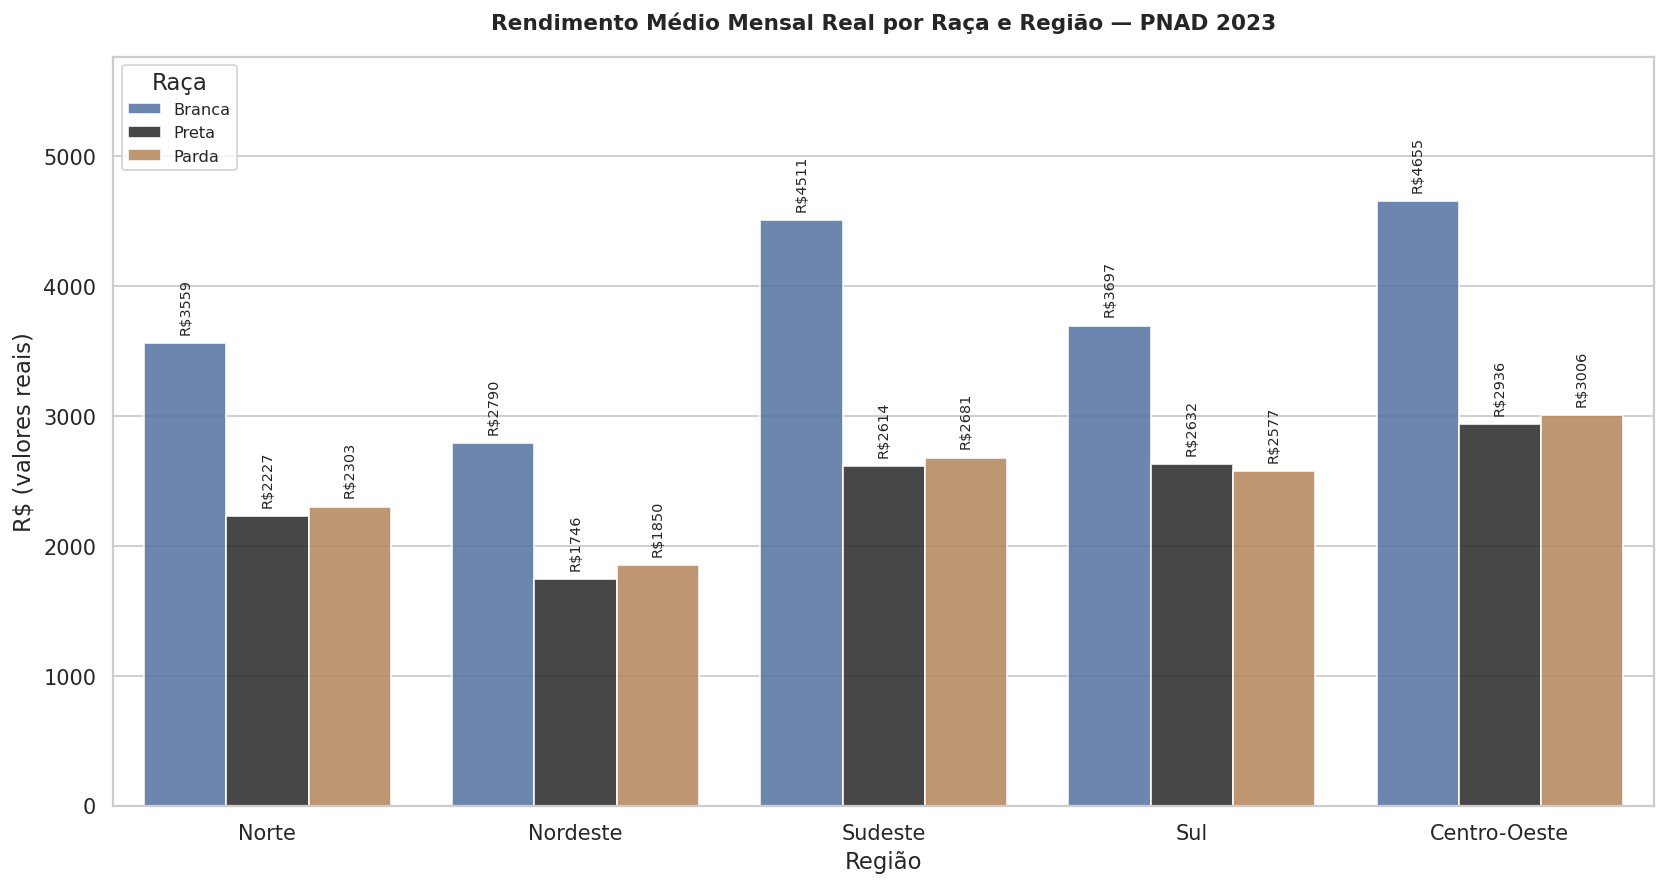

In [15]:
# Rendimento por raça e região — PNAD 2023
regioes_br = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']
df_rend_reg = df_rend[df_rend['local'].isin(regioes_br)].copy()
df_rend_reg_melt = df_rend_reg[
    ['local','2023_Branca','2023_Preta','2023_Parda']].copy()
df_rend_reg_melt.columns = ['Região','Branca','Preta','Parda']
df_melt = df_rend_reg_melt.melt(
    id_vars='Região', var_name='Raça', value_name='Rendimento (R$)')

fig, ax = plt.subplots(figsize=(13, 7))   # mais altura = rótulos não somem
sns.barplot(data=df_melt, x='Região', y='Rendimento (R$)', hue='Raça',
            palette={'Branca':'#4C72B0','Preta':'#2d2d2d','Parda':'#C4874F'},
            ax=ax, alpha=0.88)

# Espaço extra no topo para os rótulos verticais
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)

ax.set_title('Rendimento Médio Mensal Real por Raça e Região — PNAD 2023',
             fontweight='bold', pad=15)
ax.set_ylabel('R$ (valores reais)')
ax.legend(title='Raça', fontsize=9, loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='R$%.0f', fontsize=8,
                 padding=5, rotation=90)

plt.tight_layout()
plt.savefig('fig_10_pnad_barras.png', bbox_inches='tight')
plt.show()


---
## 10. Correlação Externa 2 — TSE 2022: Representatividade Racial dos Eleitos <a id='10'></a>

> **Fonte:** TSE — Repositório de Dados Eleitorais, Eleições Gerais 2022.  
> **Nota temporal:** dados de 2022, mais próximos disponíveis da pesquisa CESOP de 2023.

In [16]:
try:
    df_tse = pd.read_csv('dados_externos/consulta_cand_2022_BRASIL.csv',
                         sep=';', encoding='latin1', low_memory=False)
    df_tse_val = df_tse[~df_tse['DS_COR_RACA'].isin(
        ['#NULO','NÃO DIVULGÁVEL','NÃO INFORMADO'])].copy()
    df_tse_val = df_tse_val[df_tse_val['DS_COR_RACA'].notna()]
    cargos = ['GOVERNADOR','SENADOR','DEPUTADO FEDERAL','DEPUTADO ESTADUAL']
    df_tse_rel = df_tse_val[df_tse_val['DS_CARGO'].isin(cargos)].copy()
    df_tse_rel['negro'] = df_tse_rel['DS_COR_RACA'].isin(['PRETA','PARDA'])
    df_tse_rel['eleito'] = df_tse_rel['DS_SIT_TOT_TURNO'].isin(
        ['ELEITO','ELEITO POR QP','ELEITO POR MÉDIA'])
    tse_ok = True
    print(f'✓ TSE carregado: {len(df_tse_rel):,} candidatos em cargos relevantes')
except Exception as e:
    tse_ok = False
    print(f'⚠ TSE não encontrado: {e}')

✓ TSE carregado: 27,739 candidatos em cargos relevantes


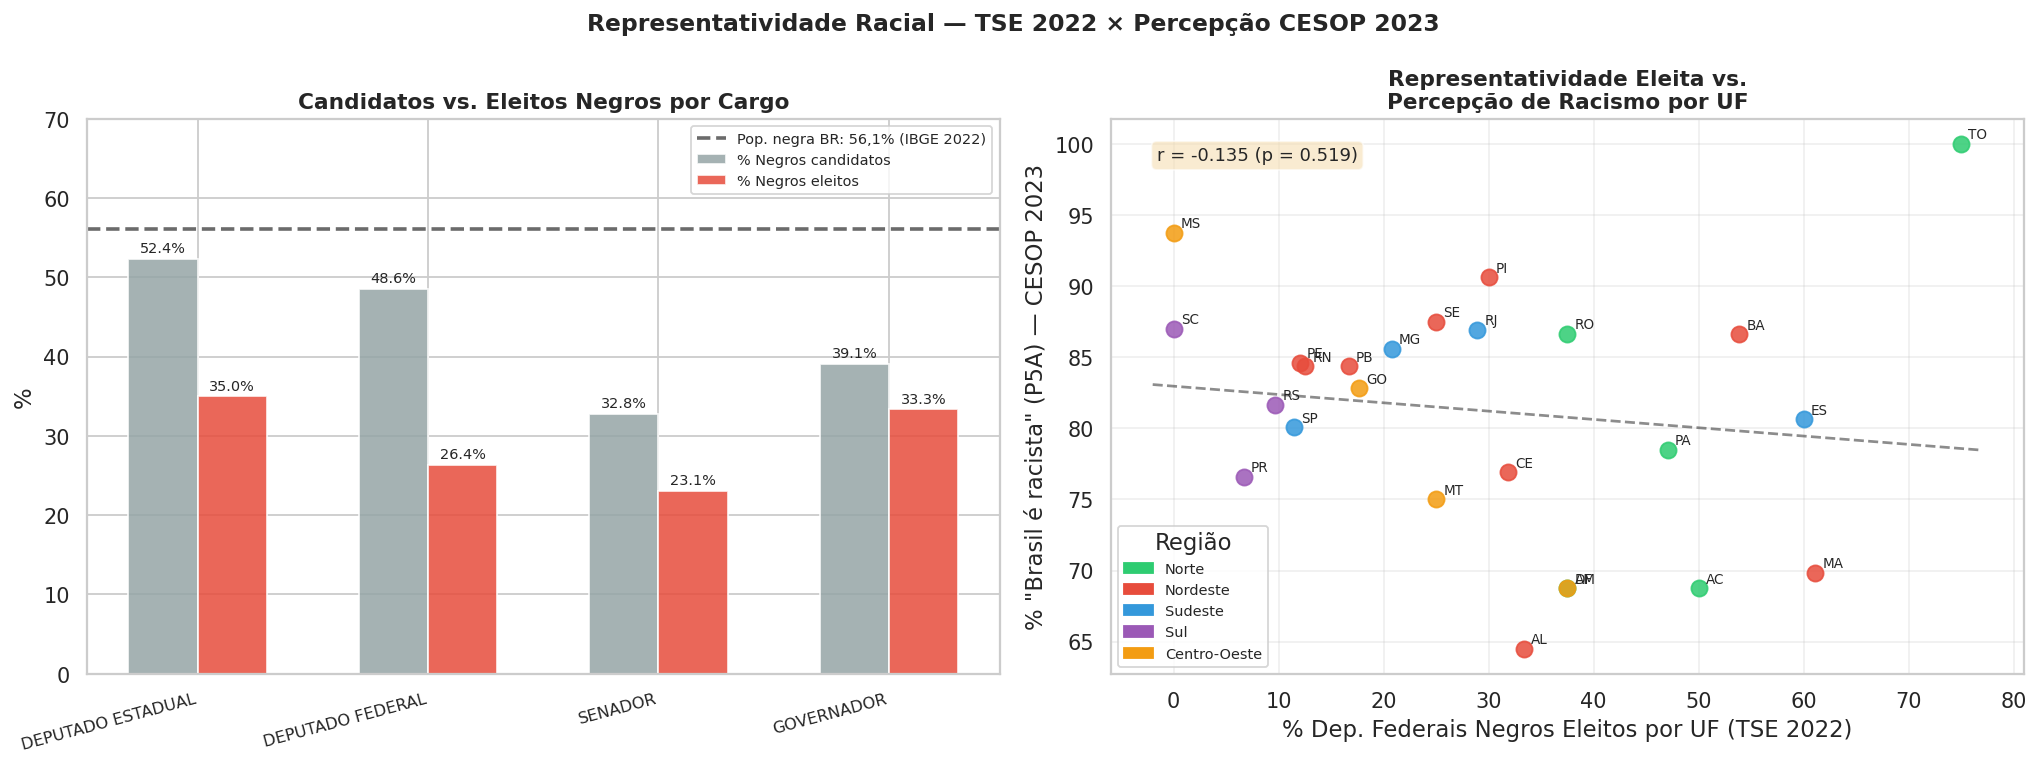

In [17]:
if tse_ok:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Representatividade Racial — TSE 2022 × Percepção CESOP 2023',
                 fontsize=13, fontweight='bold')

    # Painel esq: % negros candidatos vs eleitos por cargo
    ax = axes[0]
    cargos_p = ['DEPUTADO ESTADUAL','DEPUTADO FEDERAL','SENADOR','GOVERNADOR']
    x = np.arange(len(cargos_p)); w = 0.3
    pct_c, pct_e = [], []
    for cargo in cargos_p:
        sub = df_tse_rel[df_tse_rel['DS_CARGO']==cargo]
        pct_c.append(sub['negro'].mean()*100)
        el = sub[sub['eleito']]
        pct_e.append(el['negro'].mean()*100 if len(el)>0 else 0)
    b1 = ax.bar(x-w/2, pct_c, w, label='% Negros candidatos', color='#95a5a6', alpha=0.85)
    b2 = ax.bar(x+w/2, pct_e, w, label='% Negros eleitos', color='#e74c3c', alpha=0.85)
    ax.axhline(56.1,color='#2d2d2d',linestyle='--',linewidth=2,alpha=0.7,
               label='Pop. negra BR: 56,1% (IBGE 2022)')
    ax.set_xticks(x); ax.set_xticklabels(cargos_p,rotation=15,ha='right',fontsize=9)
    ax.set_ylabel('%'); ax.set_title('Candidatos vs. Eleitos Negros por Cargo')
    ax.legend(fontsize=8); ax.set_ylim(0,70)
    for c in [b1,b2]: ax.bar_label(c,fmt='%.1f%%',fontsize=8,padding=2)

    # Painel dir: % negros eleitos por UF × percepção CESOP P5A
    ax2 = axes[1]
    dep_fed = df_tse_rel[df_tse_rel['DS_CARGO']=='DEPUTADO FEDERAL']
    uf_tse = dep_fed.groupby('SG_UF').apply(
        lambda g: pd.Series({'eleitos':g['eleito'].sum(),
                             'pct_negros':(g['eleito']&g['negro']).sum()/g['eleito'].sum()*100
                             if g['eleito'].sum()>0 else 0})).reset_index()
    uf_tse.columns = ['uf_sigla','eleitos','pct_negros_eleitos']

    perc_uf2 = (df.groupby('uf_sigla')['P5A_bin'].mean()*100).reset_index()
    perc_uf2.columns = ['uf_sigla','perc_racismo']
    df_tse_merge = uf_tse[uf_tse['eleitos']>=5].merge(perc_uf2, on='uf_sigla')
    df_tse_merge['regiao'] = df_tse_merge['uf_sigla'].map(MAPA_REGIAO)

    for _, row in df_tse_merge.iterrows():
        cor = COR_REGIAO.get(row['regiao'],'#999')
        ax2.scatter(row['pct_negros_eleitos'], row['perc_racismo'],
                    color=cor, s=80, zorder=3, alpha=0.85)
        ax2.annotate(row['uf_sigla'],(row['pct_negros_eleitos'],row['perc_racismo']),
                     textcoords='offset points',xytext=(4,3),fontsize=7.5)

    if len(df_tse_merge)>=3:
        r, p = pearsonr(df_tse_merge['pct_negros_eleitos'], df_tse_merge['perc_racismo'])
        z = np.polyfit(df_tse_merge['pct_negros_eleitos'], df_tse_merge['perc_racismo'],1)
        x_l = np.linspace(df_tse_merge['pct_negros_eleitos'].min()-2,
                           df_tse_merge['pct_negros_eleitos'].max()+2,100)
        ax2.plot(x_l, np.poly1d(z)(x_l),'k--',alpha=0.5,linewidth=1.5)
        ax2.text(0.05,0.95,f'r = {r:.3f} (p = {p:.3f})',transform=ax2.transAxes,
                 fontsize=10,va='top',bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.6))

    handles = [mpatches.Patch(color=c,label=r) for r,c in COR_REGIAO.items()]
    ax2.legend(handles=handles,title='Região',fontsize=8)
    ax2.set_xlabel('% Dep. Federais Negros Eleitos por UF (TSE 2022)')
    ax2.set_ylabel('% "Brasil é racista" (P5A) — CESOP 2023')
    ax2.set_title('Representatividade Eleita vs.\nPercepção de Racismo por UF')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig_11_tse.png', bbox_inches='tight')
    plt.show()

---
## 11. Correlação Externa 3 — CNJ 2023: Composição Racial do Judiciário <a id='11'></a>

> **Fonte:** CNJ — DataJud / Censo do Poder Judiciário 2023.  
> **Pergunta:** A sub-representação negra piora conforme sobe na hierarquia do Judiciário?  
> Como isso se relaciona com a percepção de racismo institucional (P19A/B)?

In [18]:
# Dados CNJ 2023 — composição racial por cargo (extraídos dos arquivos xlsx)
cnj = pd.DataFrame({
    'Cargo':       ['Servidores', 'Juízes', 'Desembargadores'],
    'Total':       [284008,        16185,    3163],
    'Pct_Branca':  [65.4,          81.3,     86.1],
    'Pct_Negra':   [28.2,          15.4,     10.7],  # preta + parda
    'Pct_Outras':  [6.4,           3.3,      3.2],
})
cnj['Pct_Pop_BR_negra'] = 56.1  # IBGE 2022

print('=== Composição Racial do Poder Judiciário (CNJ 2023) ===')
print(cnj[['Cargo','Total','Pct_Branca','Pct_Negra']].to_string(index=False))
print()
print('Pop. negra no Brasil (IBGE 2022): 56,1%')
print()
print('Pirâmide de exclusão:')
for _, row in cnj.iterrows():
    deficit = row['Pct_Pop_BR_negra'] - row['Pct_Negra']
    print(f"  {row['Cargo']}: {row['Pct_Negra']:.1f}% negros (déficit de {deficit:.1f} p.p.)")

=== Composição Racial do Poder Judiciário (CNJ 2023) ===
          Cargo  Total  Pct_Branca  Pct_Negra
     Servidores 284008        65.4       28.2
         Juízes  16185        81.3       15.4
Desembargadores   3163        86.1       10.7

Pop. negra no Brasil (IBGE 2022): 56,1%

Pirâmide de exclusão:
  Servidores: 28.2% negros (déficit de 27.9 p.p.)
  Juízes: 15.4% negros (déficit de 40.7 p.p.)
  Desembargadores: 10.7% negros (déficit de 45.4 p.p.)


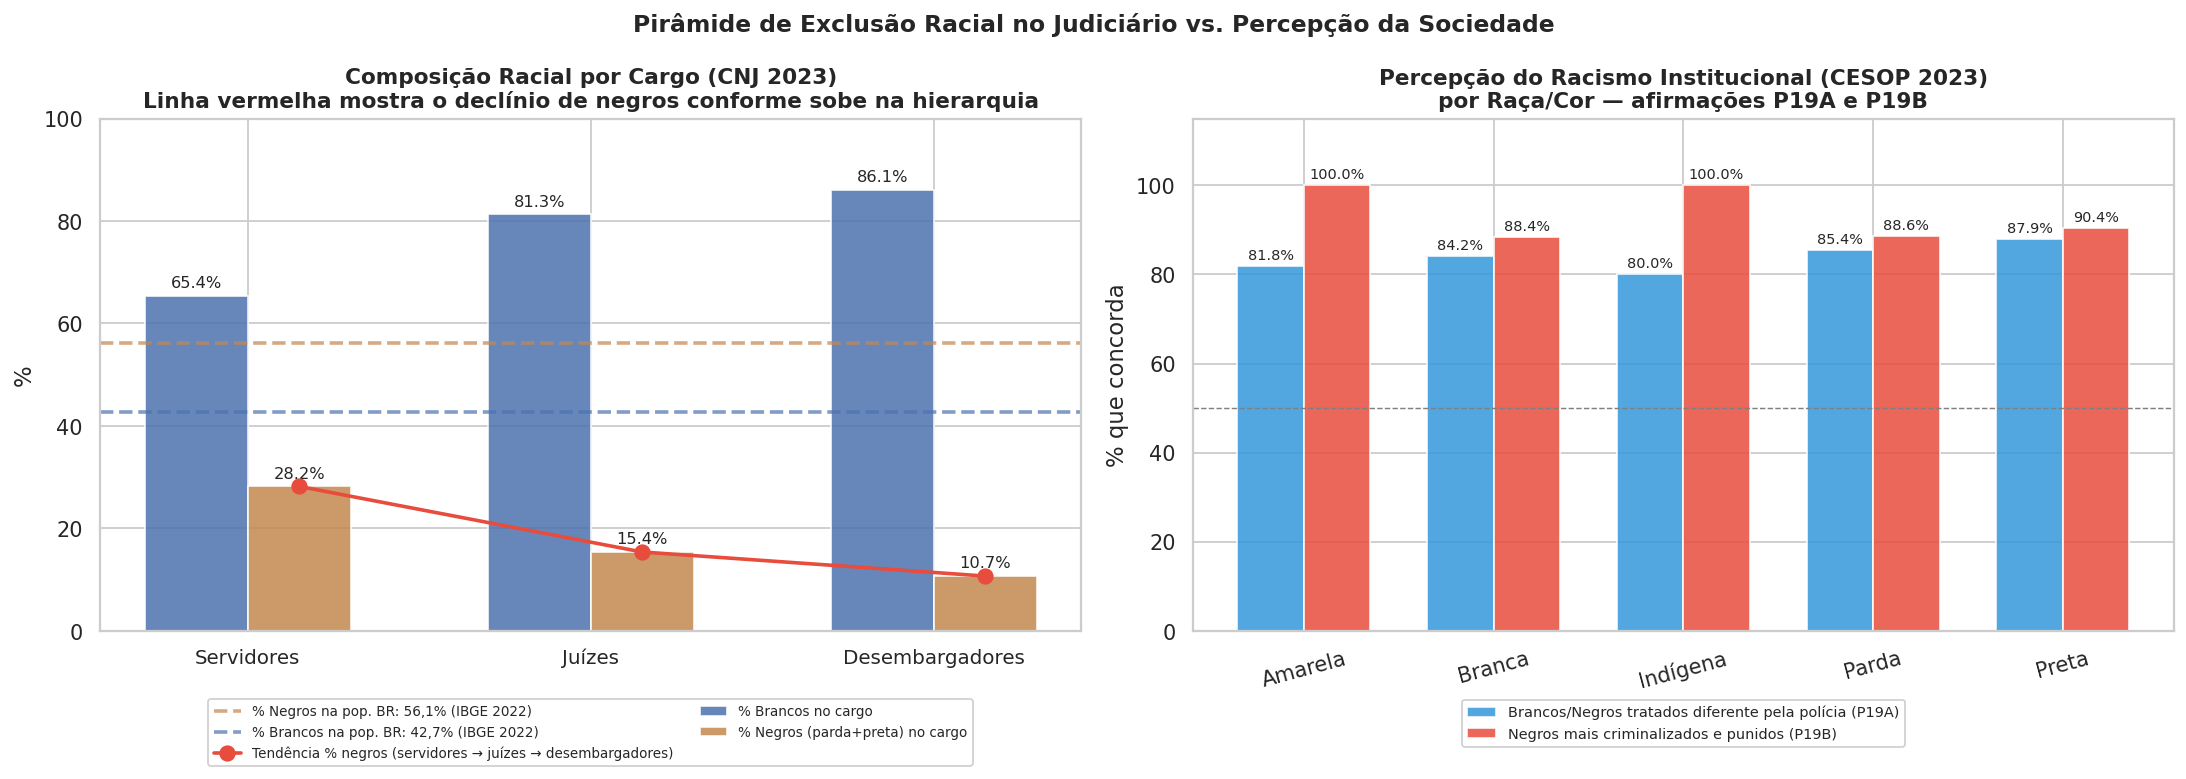

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Pirâmide de Exclusão Racial no Judiciário vs. Percepção da Sociedade',
             fontsize=13, fontweight='bold')

# --- Painel esq: pirâmide de exclusão ---
ax = axes[0]
x = np.arange(len(cnj)); w = 0.3

b1 = ax.bar(x - w/2, cnj['Pct_Branca'], w,
            label='% Brancos no cargo', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, cnj['Pct_Negra'],  w,
            label='% Negros (parda+preta) no cargo', color='#C4874F', alpha=0.85)

ax.axhline(56.1, color='#C4874F', linestyle='--', linewidth=2, alpha=0.7,
           label='% Negros na pop. BR: 56,1% (IBGE 2022)')
ax.axhline(42.7, color='#4C72B0', linestyle='--', linewidth=2, alpha=0.7,
           label='% Brancos na pop. BR: 42,7% (IBGE 2022)')

# Linha conectando a evolução dos negros entre cargos (substitui as setas)
ax.plot(x + w/2, cnj['Pct_Negra'].values,
        color='#e74c3c', linewidth=2, marker='o', markersize=8, zorder=5,
        label='Tendência % negros (servidores → juízes → desembargadores)')

ax.set_xticks(x)
ax.set_xticklabels(cnj['Cargo'], fontsize=11)
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.set_title('Composição Racial por Cargo (CNJ 2023)\n'
             'Linha vermelha mostra o declínio de negros conforme sobe na hierarquia')

# Legenda em baixo para não cobrir barras de Desembargadores
ax.legend(fontsize=7.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=2, framealpha=0.9)

for c in [b1, b2]:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=3)

# --- Painel dir: percepção P19A e P19B por raça ---
ax2 = axes[1]
perc_p19 = df.groupby('raca_label')[['P19A_bin','P19B_bin']].mean() * 100
perc_p19.columns = [
    'Brancos/Negros tratados diferente pela polícia (P19A)',
    'Negros mais criminalizados e punidos (P19B)'
]

x2 = np.arange(len(perc_p19)); w2 = 0.35
b3 = ax2.bar(x2 - w2/2, perc_p19.iloc[:,0], w2,
              label=perc_p19.columns[0], color='#3498db', alpha=0.85)
b4 = ax2.bar(x2 + w2/2, perc_p19.iloc[:,1], w2,
              label=perc_p19.columns[1], color='#e74c3c', alpha=0.85)

ax2.set_xticks(x2)
ax2.set_xticklabels(perc_p19.index, rotation=15)
ax2.set_ylabel('% que concorda')
ax2.set_ylim(0, 115)
ax2.set_title('Percepção do Racismo Institucional (CESOP 2023)\n'
              'por Raça/Cor — afirmações P19A e P19B')
ax2.legend(fontsize=8, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), ncol=1, framealpha=0.9)
ax2.axhline(50, color='gray', linestyle='--', linewidth=0.8)
for c in [b3, b4]:
    ax2.bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # espaço embaixo para legenda
plt.savefig('fig_12_cnj.png', bbox_inches='tight')
plt.show()


---
## 12. PCA — Dimensões Latentes na Percepção do Racismo <a id='12'></a>

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_pca = [c+'_bin' for c in ITENS_P5]
data_pca = df[cols_pca].dropna()
X = StandardScaler().fit_transform(data_pca)

pca = PCA(n_components=3)
comps = pca.fit_transform(X)
var = pca.explained_variance_ratio_*100

print('Variância explicada:')
for i,v in enumerate(var): print(f'  PC{i+1}: {v:.1f}%')
print(f'  Total: {sum(var):.1f}%')

loadings = pd.DataFrame(pca.components_.T,
    index=list(ITENS_P5.values()),
    columns=[f'PC{i+1} ({v:.1f}%)' for i,v in enumerate(var)])
print('\nLoadings:'); print(loadings.round(3))

Variância explicada:
  PC1: 34.9%
  PC2: 14.7%
  PC3: 12.3%
  Total: 61.9%

Loadings:
                             PC1 (34.9%)  PC2 (14.7%)  PC3 (12.3%)
Brasil é racista                   0.318       -0.322       -0.663
Eu sofri racismo                   0.342       -0.165        0.718
Tenho atitudes racistas            0.268        0.638        0.057
Presenciei racismo                 0.428       -0.323        0.054
Convivo c/ vítimas                 0.471       -0.214        0.036
Convivo c/ quem age racista        0.447        0.112       -0.072
Minha família é racista            0.323        0.547       -0.179


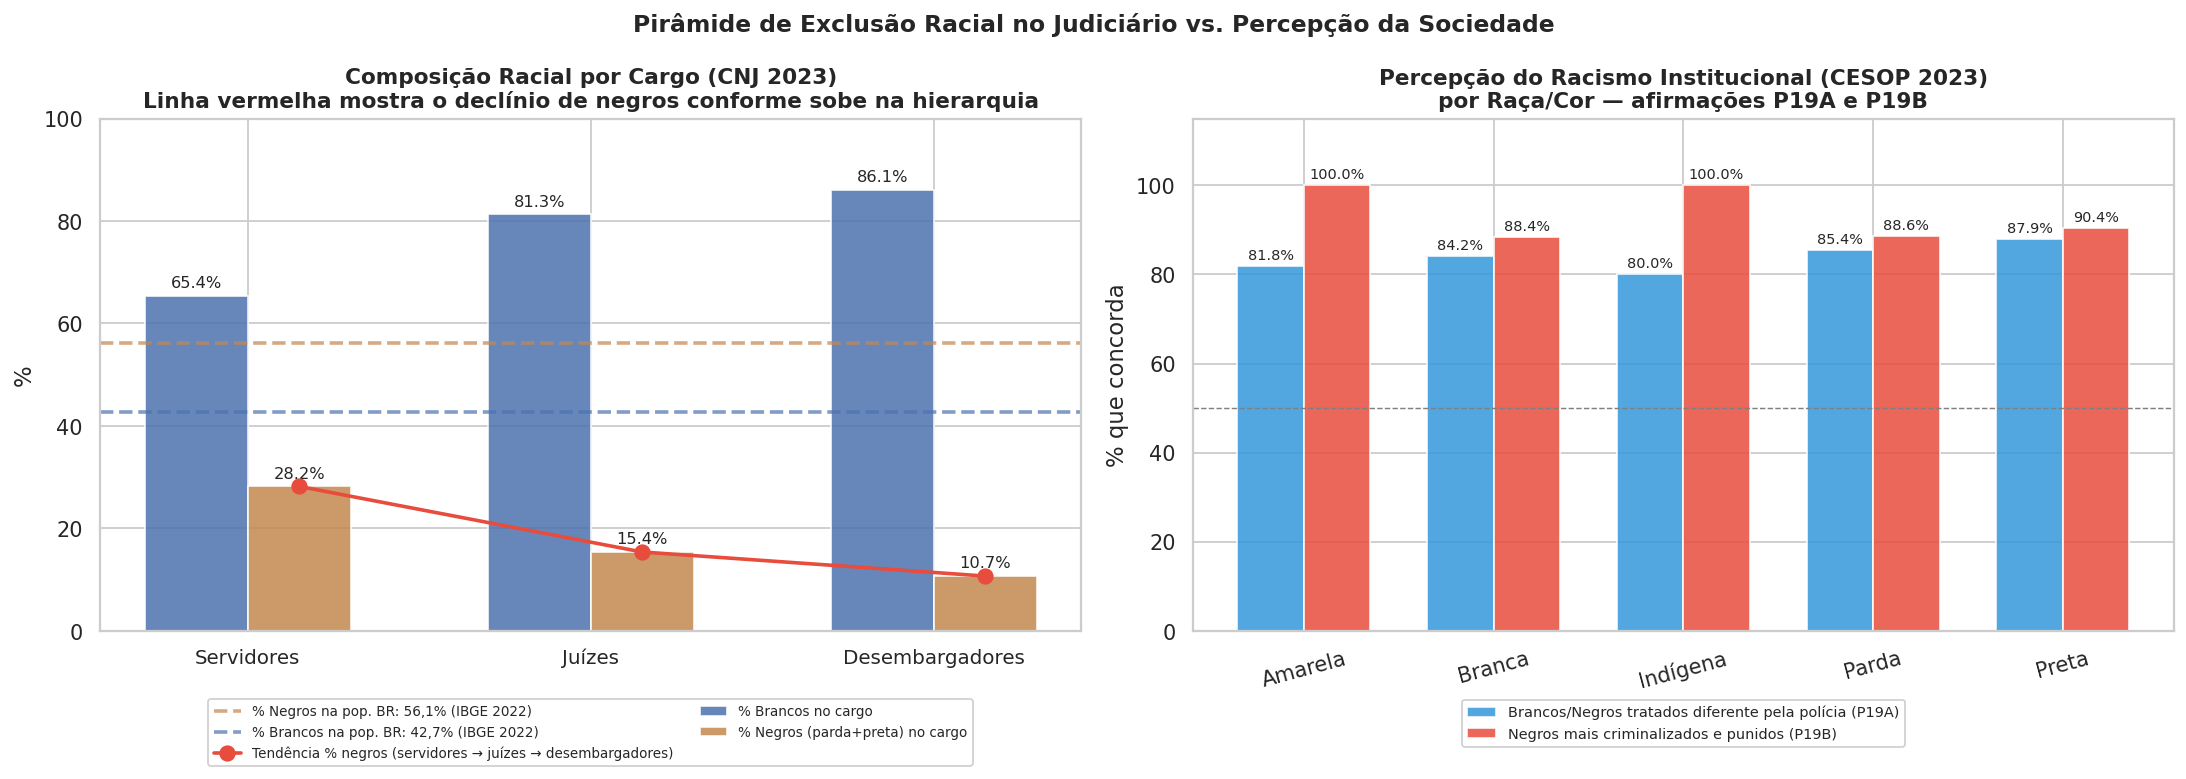

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Pirâmide de Exclusão Racial no Judiciário vs. Percepção da Sociedade',
             fontsize=13, fontweight='bold')

# --- Painel esq: pirâmide de exclusão ---
ax = axes[0]
x = np.arange(len(cnj)); w = 0.3

b1 = ax.bar(x - w/2, cnj['Pct_Branca'], w,
            label='% Brancos no cargo', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, cnj['Pct_Negra'],  w,
            label='% Negros (parda+preta) no cargo', color='#C4874F', alpha=0.85)

ax.axhline(56.1, color='#C4874F', linestyle='--', linewidth=2, alpha=0.7,
           label='% Negros na pop. BR: 56,1% (IBGE 2022)')
ax.axhline(42.7, color='#4C72B0', linestyle='--', linewidth=2, alpha=0.7,
           label='% Brancos na pop. BR: 42,7% (IBGE 2022)')

# Linha conectando a evolução dos negros entre cargos (substitui as setas)
ax.plot(x + w/2, cnj['Pct_Negra'].values,
        color='#e74c3c', linewidth=2, marker='o', markersize=8, zorder=5,
        label='Tendência % negros (servidores → juízes → desembargadores)')

ax.set_xticks(x)
ax.set_xticklabels(cnj['Cargo'], fontsize=11)
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.set_title('Composição Racial por Cargo (CNJ 2023)\n'
             'Linha vermelha mostra o declínio de negros conforme sobe na hierarquia')

# Legenda em baixo para não cobrir barras de Desembargadores
ax.legend(fontsize=7.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=2, framealpha=0.9)

for c in [b1, b2]:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=3)

# --- Painel dir: percepção P19A e P19B por raça ---
ax2 = axes[1]
perc_p19 = df.groupby('raca_label')[['P19A_bin','P19B_bin']].mean() * 100
perc_p19.columns = [
    'Brancos/Negros tratados diferente pela polícia (P19A)',
    'Negros mais criminalizados e punidos (P19B)'
]

x2 = np.arange(len(perc_p19)); w2 = 0.35
b3 = ax2.bar(x2 - w2/2, perc_p19.iloc[:,0], w2,
              label=perc_p19.columns[0], color='#3498db', alpha=0.85)
b4 = ax2.bar(x2 + w2/2, perc_p19.iloc[:,1], w2,
              label=perc_p19.columns[1], color='#e74c3c', alpha=0.85)

ax2.set_xticks(x2)
ax2.set_xticklabels(perc_p19.index, rotation=15)
ax2.set_ylabel('% que concorda')
ax2.set_ylim(0, 115)
ax2.set_title('Percepção do Racismo Institucional (CESOP 2023)\n'
              'por Raça/Cor — afirmações P19A e P19B')
ax2.legend(fontsize=8, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), ncol=1, framealpha=0.9)
ax2.axhline(50, color='gray', linestyle='--', linewidth=0.8)
for c in [b3, b4]:
    ax2.bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # espaço embaixo para legenda
plt.savefig('fig_12_cnj.png', bbox_inches='tight')
plt.show()


---
## 13. Conclusões <a id='13'></a>

### Alinhamento Temporal das Fontes

| Fonte | Período | Alinhamento com CESOP (abril 2023) |
|-------|---------|-------------------------------------|
| CESOP/IPEC 04829 | Abril 2023 | — referência principal |
| PNAD Contínua (IBGE) | Anual 2023 | ✅ mesmo ano |
| TSE — Candidatos | Outubro 2022 | ⚠️ ~6 meses antes — mais próximo disponível |
| CNJ — DataJud | 2023 | ✅ mesmo ano |

### Principais Achados

| # | Análise | Achado |
|---|---------|--------|
| 1 | **Paradoxo da Consciência Racial** | Gap de ~75 p.p. entre "Brasil é racista" e "tenho atitudes racistas" — mais pronunciado entre brancos |
| 2 | **Distância Social** | Percepção declina conforme se aproxima do "eu"; declínio mais abrupto entre pardos |
| 3 | **Cotas** | PcD: 88% a favor; LGBTQIA+: 56%. Padrão sugere apoio baseado em "merecimento percebido" |
| 4 | **Motor das desigualdades** | Respondentes de maior renda preferem "classe social" a "raça" — efeito de mascaramento |
| 5 | **Def. de racismo** | Apenas 23% adota def. estrutural; cresce com escolaridade (18% → 27%) |
| 6 | **Racismo policial** | Alta percepção mesmo entre brancos; cai abruptamente à direita |
| 7 | **PNAD 2023** | Gap salarial branca/preta varia de 22% (AP) a 152% (PB); **sem correlação significativa** com percepção de racismo por UF (r=−0.02) — paradoxo da normalização |
| 8 | **TSE 2022** | Negros: 56% da pop., mas apenas 32% dos Dep. Federais eleitos; SC: 0% de eleitos negros |
| 9 | **CNJ 2023** | Pirâmide de exclusão confirmada: 28% negros entre servidores → 15% entre juízes → 11% entre desembargadores |

### Limitações
- Correlações por UF têm N=25 — interpretações com cautela
- Pesquisa CESOP captura percepções declaradas (possível viés de desejabilidade social)
- TSE é de 2022; CNJ e PNAD são de 2023 — alinhamento temporal imperfeito para o TSE

---
## Referências

- CESOP/IPEC (2023). *Pesquisa 04829 — Percepção dos Brasileiros sobre o Racismo no Brasil*. Unicamp.
- IBGE (2023). *PNAD Contínua Anual* — Tabelas 10374, 10372, 10361. https://sidra.ibge.gov.br
- TSE (2022). *Repositório de Dados Eleitorais — Candidatos 2022*. https://dadosabertos.tse.jus.br
- CNJ (2023). *DataJud / Censo do Poder Judiciário*. https://www.cnj.jus.br

---
## Declaração de Uso de Inteligência Artificial

Este notebook foi elaborado **com auxílio de Inteligência Artificial** (Claude, Anthropic — https://claude.ai).

O uso de IA compreendeu:
- Sugestão e estruturação das análises exploratórias
- Diagnóstico e correção de bugs — em especial a lógica de resposta múltipla cascateada (variáveis P7, P8)
- Geração e refinamento iterativo do código de visualização
- Orientação na integração e alinhamento temporal das bases externas (PNAD, TSE, CNJ)

Todo o código foi **revisado, executado e validado pela equipe**.  
As interpretações, conclusões e escolhas analíticas são de **responsabilidade dos autores**.

In [22]:
import glob
figs = sorted(glob.glob('fig_*.png'))
print(f'✓ {len(figs)} figuras geradas:')
for f in figs: print(f'  {f}')

✓ 12 figuras geradas:
  fig_01_perfil_amostra.png
  fig_02_paradoxo.png
  fig_03_heatmap_p5.png
  fig_04_distancia_social.png
  fig_05_cotas.png
  fig_06_motor_desigualdades.png
  fig_07_definicao_racismo.png
  fig_08_racismo_policial.png
  fig_09_pnad_correlacao.png
  fig_10_pnad_barras.png
  fig_11_tse.png
  fig_12_cnj.png
